In [46]:
# ============================================================
# WildToolBench Strategy Analysis
#
# Section 1: Imports & Configuration
# ============================================================

from pathlib import Path
from collections import defaultdict, Counter
import json
import math
import statistics

import numpy as np
import pandas as pd

!pip install matplotlib
import matplotlib.pyplot as plt

# nicer notebook display
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

# ------------------------------------------------------------
# Project paths
# ------------------------------------------------------------

PROJECT_ROOT = Path.cwd()

RESULT_ROOT = PROJECT_ROOT / "result_120B"
DATA_FILE = PROJECT_ROOT / "data" / "Wild-Tool-Bench.jsonl"

assert RESULT_ROOT.exists(), f"Could not find {RESULT_ROOT}"
assert DATA_FILE.exists(), f"Could not find {DATA_FILE}"

print(f"Project root : {PROJECT_ROOT}")
print(f"Result folder: {RESULT_ROOT}")


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Project root : /home/aherrman/ToolSelectionBenchmark/wild-tool-bench
Result folder: /home/aherrman/ToolSelectionBenchmark/wild-tool-bench/result_120B


In [47]:
# ============================================================
# Generic helper functions
# ============================================================

def read_jsonl(path: Path):
    """Read a JSONL file into a list of dictionaries."""
    rows = []

    if not path.exists():
        return rows

    with open(path, encoding="utf-8") as f:
        for line in f:
            line = line.strip()

            if not line:
                continue

            rows.append(json.loads(line))

    return rows


def safe_float(value):
    try:
        value = float(value)
        return value if math.isfinite(value) else None
    except (TypeError, ValueError):
        return None


def numeric_total(value, fallback=None):
    """
    Handles WTB's habit of storing either a scalar
    or a list of values.
    """

    if isinstance(value, list):
        vals = [safe_float(v) for v in value]
        vals = [v for v in vals if v is not None]

        if vals:
            return sum(vals)

        return numeric_total(fallback)

    parsed = safe_float(value)

    if parsed is not None:
        return parsed

    if fallback is not None:
        return numeric_total(fallback)

    return None


def mean(values):
    values = list(values)
    return statistics.mean(values) if values else None


def median(values):
    values = list(values)
    return statistics.median(values) if values else None

# ============================================================
# Selector usage per benchmark task
# ============================================================

def selector_task_metrics(rows):
    """
    Aggregate selector token usage and latency per benchmark task.

    Multiple selector calls for the same task are summed.

    Returns
    -------
    dict keyed by (task_id, task_idx)

    {
        (task_id, task_idx): {
            "selector_input_tokens": ...,
            "selector_output_tokens": ...,
            "selector_latency": ...
        }
    }
    """

    output = defaultdict(
        lambda: {
            "selector_input_tokens": 0.0,
            "selector_output_tokens": 0.0,
            "selector_latency": 0.0,
        }
    )

    for row in rows:

        try:
            key = (
                str(row["test_entry_id"]),
                int(row["task_idx"])
            )
        except (KeyError, TypeError, ValueError):
            continue

        metadata = row.get("metadata", {}) or {}

        output[key]["selector_input_tokens"] += (
            numeric_total(
                metadata.get("selector_input_tokens")
            )
            or 0
        )

        output[key]["selector_output_tokens"] += (
            numeric_total(
                metadata.get("selector_output_tokens")
            )
            or 0
        )

        output[key]["selector_latency"] += (
            numeric_total(
                metadata.get("selector_latency_s")
            )
            or 0
        )

    return output

In [48]:
# ============================================================
# Automatically discover all benchmark runs
# ============================================================

def discover_runs(result_root: Path):
    """
    Discover every strategy automatically.

    Returns
    -------
    dict

    {
        "in_context/langgraph": {
            "result": Path(...),
            "metrics": Path(...),
            "selection": Path(...)
        },
        ...
    }
    """

    runs = {}

    for result_file in sorted(result_root.rglob("Wild-Tool-Bench_result.jsonl")):

        run_name = result_file.parent.relative_to(result_root).as_posix()

        run = {
            "result": result_file,
            "metrics": result_file.with_name(
                "Wild-Tool-Bench_metrics_summary.jsonl"
            ),
            "selection": result_file.parent.parent / "tool_selection_logs.jsonl",
        }

        runs[run_name] = run

    return runs

In [49]:
# ============================================================
# Discover available benchmark runs
# ============================================================

runs = discover_runs(RESULT_ROOT)

print(f"Found {len(runs)} benchmark runs\n")

for name, files in runs.items():

    print("=" * 60)
    print(name)

    for key, path in files.items():
        print(f"  {key:<10} {path.exists()}   {path}")

Found 6 benchmark runs

hierarchical/langgraph
  result     True   /home/aherrman/ToolSelectionBenchmark/wild-tool-bench/result_120B/hierarchical/langgraph/Wild-Tool-Bench_result.jsonl
  metrics    True   /home/aherrman/ToolSelectionBenchmark/wild-tool-bench/result_120B/hierarchical/langgraph/Wild-Tool-Bench_metrics_summary.jsonl
  selection  True   /home/aherrman/ToolSelectionBenchmark/wild-tool-bench/result_120B/hierarchical/tool_selection_logs.jsonl
in_context/langgraph
  result     True   /home/aherrman/ToolSelectionBenchmark/wild-tool-bench/result_120B/in_context/langgraph/Wild-Tool-Bench_result.jsonl
  metrics    True   /home/aherrman/ToolSelectionBenchmark/wild-tool-bench/result_120B/in_context/langgraph/Wild-Tool-Bench_metrics_summary.jsonl
  selection  True   /home/aherrman/ToolSelectionBenchmark/wild-tool-bench/result_120B/in_context/tool_selection_logs.jsonl
qwen3_embedding/langgraph
  result     True   /home/aherrman/ToolSelectionBenchmark/wild-tool-bench/result_120B/qwen3_

In [50]:
# ============================================================
# Load benchmark data
# ============================================================

benchmark = read_jsonl(DATA_FILE)

print(f"Loaded {len(benchmark)} benchmark entries")

Loaded 256 benchmark entries


In [51]:
# ============================================================
# Benchmark lookup tables
# ============================================================

gold_records = {}

task_metadata = {}

task_number = 0

for record in benchmark:

    entry_id = str(record["id"])

    gold_records[entry_id] = record

    tasks = record.get("english_tasks", [])
    task_types = record.get("english_task_types", [])

    for task_idx, task in enumerate(tasks):

        task_number += 1

        task_metadata[(entry_id, task_idx)] = {
            "benchmark_task_number": task_number,
            "task_text": task,
            "task_type": (
                task_types[task_idx]
                if task_idx < len(task_types)
                else "unknown"
            )
        }

print(f"Loaded metadata for {len(task_metadata)} tasks")

Loaded metadata for 1024 tasks


In [52]:
# ============================================================
# Convert WTB result records into individual tasks
# ============================================================

def task_index(rows):
    """
    Convert WildToolBench result records into a dictionary
    indexed by (entry_id, task_idx).
    """

    output = {}

    for record in rows:

        entry_id = str(record.get("id", ""))

        result = record.get("result", [])
        metrics = record.get("metrics", {}) or {}

        # Metrics can contain additional per-task information
        per_task = {
            int(x["task_idx"]): x
            for x in metrics.get("per_task", [])
            if isinstance(x, dict) and "task_idx" in x
        }

        if not isinstance(result, list):
            result = []

        for fallback_idx, item in enumerate(result):

            if not isinstance(item, dict):
                item = {
                    "action_name_label": "error",
                    "is_optimal": False
                }

            log = item.get("inference_log", {}) or {}

            idx = log.get("task_idx", fallback_idx)

            try:
                idx = int(idx)
            except (TypeError, ValueError):
                idx = fallback_idx

            metric = per_task.get(idx, {})

            # Number of agent steps
            step_count = metric.get("steps")

            if step_count is None:
                step_count = len([
                    key
                    for key in log
                    if str(key).startswith("step_")
                ])

            input_tokens = numeric_total(
                item.get("input_token_count"),
                metric.get("input_tokens")
            )

            output_tokens = numeric_total(
                item.get("output_token_count"),
                metric.get("output_tokens")
            )

            total_tokens = numeric_total(
                metric.get("total_tokens")
            )

            # Fall back to input + output
            if total_tokens is None:
                if input_tokens is not None or output_tokens is not None:
                    total_tokens = (
                        (input_tokens or 0)
                        + (output_tokens or 0)
                    )

            output[(entry_id, idx)] = {

                "id": entry_id,
                "task_idx": idx,

                # Evaluation
                "label": item.get(
                    "action_name_label",
                    "error"
                ),

                "correct": (
                    item.get("action_name_label")
                    == "correct"
                ),

                "optimal": bool(
                    item.get("is_optimal", False)
                ),

                # Usage
                "input_tokens": input_tokens,
                "output_tokens": output_tokens,
                "total_tokens": total_tokens,

                # Timing
                "latency": numeric_total(
                    item.get("latency"),
                    metric.get("llm_latency_s")
                ),

                "wall_time": numeric_total(
                    item.get("task_wall_time_s"),
                    metric.get("task_wall_time_s")
                ),

                "steps": int(step_count or 0),

                # Keep original result for later analyses
                "record": item
            }

    return output

In [53]:
# ============================================================
# Extract tool calls from a task's inference log
# ============================================================

def tool_names_from_task(task):
    """
    Extract the ordered sequence of tool names called
    by the agent during a task.
    """

    names = []

    log = (
        task
        .get("record", {})
        .get("inference_log", {})
        or {}
    )

    def step_number(key):
        key = str(key)

        if key.startswith("step_"):
            suffix = key.split("_")[-1]

            if suffix.isdigit():
                return int(suffix)

        return -1

    for key in sorted(log, key=step_number):

        if not str(key).startswith("step_"):
            continue

        step = log[key]

        if not isinstance(step, dict):
            continue

        inference_output = (
            step.get("inference_output", {})
            or {}
        )

        if not isinstance(inference_output, dict):
            continue

        calls = inference_output.get(
            "tool_calls",
            []
        )

        if not isinstance(calls, list):
            continue

        for call in calls:

            if not isinstance(call, dict):
                continue

            function = call.get(
                "function",
                {}
            ) or {}

            if isinstance(function, dict):
                name = function.get("name")
            else:
                name = call.get("name")

            if name:
                names.append(str(name))

    return names

In [54]:
# ============================================================
# Build one dataframe containing ALL benchmark tasks
# for ALL strategies
#
# Includes:
# - executing LLM tokens / latency
# - selector tokens / latency
# - complete pipeline tokens / latency
#
# Missing result = failed / no-result task
# ============================================================

rows = []

if 'runs' not in globals():
    runs = discover_runs(RESULT_ROOT)

for strategy, files in runs.items():

    print(f"Loading {strategy}")

    # --------------------------------------------------------
    # Executing LLM results
    # --------------------------------------------------------

    result_rows = read_jsonl(files["result"])
    result_tasks = task_index(result_rows)

    # --------------------------------------------------------
    # Selector logs
    #
    # Strategies without selector logs simply get zero
    # selector overhead.
    # --------------------------------------------------------

    selection_file = files.get("selection")

    if selection_file is not None and selection_file.exists():

        selection_rows = read_jsonl(selection_file)

        selector_metrics = selector_task_metrics(
            selection_rows
        )

    else:
        selector_metrics = {}

    # --------------------------------------------------------
    # Iterate over ALL benchmark tasks
    # --------------------------------------------------------

    for key, meta in task_metadata.items():

        entry_id, task_idx = key

        task = result_tasks.get(key)

        has_result = task is not None

        # Selector usage for this task
        selector = selector_metrics.get(
            key,
            {
                "selector_input_tokens": 0.0,
                "selector_output_tokens": 0.0,
                "selector_latency": 0.0,
            }
        )

        selector_input = (
            selector["selector_input_tokens"]
        )

        selector_output = (
            selector["selector_output_tokens"]
        )

        selector_total = (
            selector_input
            + selector_output
        )

        selector_latency = (
            selector["selector_latency"]
        )

        # ====================================================
        # No executing-LLM result
        # ====================================================

        if not has_result:

            rows.append({

                # Benchmark
                "strategy": strategy,
                "task_id": entry_id,
                "task_idx": task_idx,

                "benchmark_task_number":
                    meta.get("benchmark_task_number"),

                "task_type":
                    meta.get("task_type"),

                "task_text":
                    meta.get("task_text"),

                # Result
                "has_result": False,
                "result_status": "No result",

                "correct": False,
                "optimal": False,

                "label": "no result",

                # --------------------------------------------
                # Executing LLM usage
                # --------------------------------------------

                "input_tokens": None,
                "output_tokens": None,
                "total_tokens": None,

                "latency": None,
                "wall_time": None,

                "steps": 0,

                # --------------------------------------------
                # Selector usage
                # --------------------------------------------

                "selector_input_tokens":
                    selector_input,

                "selector_output_tokens":
                    selector_output,

                "selector_total_tokens":
                    selector_total,

                "selector_latency":
                    selector_latency,

                # --------------------------------------------
                # Pipeline usage
                #
                # Selector may have run even though the
                # executing LLM later failed.
                # --------------------------------------------

                "pipeline_total_tokens":
                    selector_total,

                "pipeline_latency":
                    selector_latency,

                "pipeline_wall_time":
                    selector_latency,

                # Tool calls
                "predicted_calls": [],
                "num_predicted_calls": 0,
            })

            continue

        # ====================================================
        # Normal result
        # ====================================================

        predicted = tool_names_from_task(task)

        correct = task["correct"]

        if correct:
            status = "Correct"

        elif task["label"] == "error":
            status = "Error result"

        else:
            status = "Incorrect"

        # Executing LLM usage
        execution_tokens = task["total_tokens"]
        execution_latency = task["latency"]

        # ----------------------------------------------------
        # Complete pipeline usage
        # ----------------------------------------------------

        pipeline_tokens = (
            (execution_tokens or 0)
            + selector_total
        )

        pipeline_latency = (
            (execution_latency or 0)
            + selector_latency
        )

        pipeline_wall_time = (
            (task["wall_time"] or 0)
            + selector_latency
        )

        rows.append({

            # Benchmark
            "strategy": strategy,
            "task_id": entry_id,
            "task_idx": task_idx,

            "benchmark_task_number":
                meta.get("benchmark_task_number"),

            "task_type":
                meta.get("task_type"),

            "task_text":
                meta.get("task_text"),

            # Result
            "has_result": True,
            "result_status": status,

            "correct": correct,
            "optimal": task["optimal"],

            "label": task["label"],

            # --------------------------------------------
            # Executing LLM usage
            # --------------------------------------------

            "input_tokens":
                task["input_tokens"],

            "output_tokens":
                task["output_tokens"],

            "total_tokens":
                execution_tokens,

            "latency":
                execution_latency,

            "wall_time":
                task["wall_time"],

            "steps":
                task["steps"],

            # --------------------------------------------
            # Selector usage
            # --------------------------------------------

            "selector_input_tokens":
                selector_input,

            "selector_output_tokens":
                selector_output,

            "selector_total_tokens":
                selector_total,

            "selector_latency":
                selector_latency,

            # --------------------------------------------
            # Complete pipeline
            # --------------------------------------------

            "pipeline_total_tokens":
                pipeline_tokens,

            "pipeline_latency":
                pipeline_latency,

            "pipeline_wall_time":
                pipeline_wall_time,

            # Tool calls
            "predicted_calls":
                predicted,

            "num_predicted_calls":
                len(predicted),
        })


task_df = pd.DataFrame(rows)

# Convenience flags
task_df["no_result"] = ~task_df["has_result"]
task_df["failed"] = ~task_df["correct"]

print(
    f"{len(task_df):,} rows "
    f"({len(runs)} strategies × "
    f"{len(task_metadata)} tasks)"
 )

display(task_df.head())

Loading hierarchical/langgraph
Loading in_context/langgraph
Loading qwen3_embedding/langgraph
Loading qwen3_embedding_context/langgraph
Loading qwen3_embedding_context_qwen3_reranker/langgraph
Loading qwen3_embedding_qwen3_reranker/langgraph
6,144 rows (6 strategies × 1024 tasks)


,strategy,task_id,task_idx,benchmark_task_number,task_type,task_text,has_result,result_status,correct,optimal,label,input_tokens,output_tokens,total_tokens,latency,wall_time,steps,selector_input_tokens,selector_output_tokens,selector_total_tokens,selector_latency,pipeline_total_tokens,pipeline_latency,pipeline_wall_time,predicted_calls,num_predicted_calls,no_result,failed
0,hierarchical/langgraph,wild_tool_bench_0,0,1,Single-Tool,I want to travel to other places this weekend....,True,Correct,True,True,correct,1336.0,646.0,1982.0,29.401599,29.429,2,109857.0,134.0,109991.0,9.280454,111973.0,38.682053,38.709454,[getCityForecast],1,False,False
1,hierarchical/langgraph,wild_tool_bench_0,1,2,Single-Tool,It doesn't look so good. Please help me check ...,True,Correct,True,True,correct,2563.0,201.0,2764.0,13.879288,13.880,2,110325.0,241.0,110566.0,12.004074,113330.0,25.883362,25.884074,[getCityForecast],1,False,False
2,hierarchical/langgraph,wild_tool_bench_0,2,3,Mixed Multi-Tool,"Check the air quality as well. If it's good, t...",True,Error result,False,False,error,2898.0,559.0,3457.0,26.526919,26.528,3,111437.0,56.0,111493.0,6.998642,114950.0,33.525561,33.526642,"[getCityAQIForecast, getCityShow]",2,False,True
3,hierarchical/langgraph,wild_tool_bench_0,3,4,Chat,Where is the specific location?,True,Correct,True,True,correct,2054.0,455.0,2509.0,20.467248,20.467,1,55850.0,118.0,55968.0,6.174772,58477.0,26.642020,26.641772,[],0,False,False
4,hierarchical/langgraph,wild_tool_bench_1,0,5,Single-Tool,I would like to know if there have been any de...,True,Correct,True,True,correct,835.0,668.0,1503.0,28.389890,28.390,2,109937.0,36.0,109973.0,5.129509,111476.0,33.519399,33.519509,[getParliamentDebates],1,False,False


In [55]:
# ============================================================
# Overall strategy metrics
# ============================================================

strategy_summary = (
    task_df
    .groupby("strategy")
    .agg(
        # benchmark coverage
        tasks=("correct", "size"),

        returned_results=("has_result", "sum"),
        no_results=("no_result", "sum"),

        # success
        correct_tasks=("correct", "sum"),
        correct_rate=("correct", "mean"),

        optimal_tasks=("optimal", "sum"),
        optimal_rate=("optimal", "mean"),

        # efficiency
        avg_input_tokens=("input_tokens", "mean"),
        avg_output_tokens=("output_tokens", "mean"),
        avg_total_tokens=("total_tokens", "mean"),
        median_total_tokens=("total_tokens", "median"),
        avg_pipeline_total_tokens=("pipeline_total_tokens", "mean"),
        median_pipeline_total_tokens=("pipeline_total_tokens", "median"),

        avg_latency=("latency", "mean"),
        median_latency=("latency", "median"),
        avg_pipeline_wall_time=("pipeline_wall_time", "mean"),
        median_pipeline_wall_time=("pipeline_wall_time", "median"),

        avg_wall_time=("wall_time", "mean"),

        avg_steps=("steps", "mean"),

        avg_predicted_calls=("num_predicted_calls", "mean"),
    )
    .reset_index()
)

strategy_summary["coverage_rate"] = (
    strategy_summary["returned_results"]
    / strategy_summary["tasks"]
)

strategy_summary["no_result_rate"] = (
    strategy_summary["no_results"]
    / strategy_summary["tasks"]
)

strategy_summary = strategy_summary.sort_values(
    "correct_rate",
    ascending=False
)

strategy_summary

,strategy,tasks,returned_results,no_results,correct_tasks,correct_rate,optimal_tasks,optimal_rate,avg_input_tokens,avg_output_tokens,avg_total_tokens,median_total_tokens,avg_pipeline_total_tokens,median_pipeline_total_tokens,avg_latency,median_latency,avg_pipeline_wall_time,median_pipeline_wall_time,avg_wall_time,avg_steps,avg_predicted_calls,coverage_rate,no_result_rate
0,hierarchical/langgraph,1024,1024,0,504,0.492188,447,0.436523,2552.322266,723.856445,3276.178711,2431.0,61198.007812,56393.0,31.068528,18.266872,35.717752,23.79686,31.074288,1.813477,0.905273,1.000000,0.000000
1,in_context/langgraph,1024,1024,0,501,0.489258,437,0.426758,162436.809570,714.254883,163151.064453,155112.5,163151.064453,155112.5,27.963353,15.066181,27.977348,15.10900,27.977348,1.786133,0.921875,1.000000,0.000000
4,qwen3_embedding_context_qwen3_reranker/langgraph,1024,1012,12,479,0.467773,417,0.407227,2331.674901,687.340909,3019.015810,2269.5,2983.636719,2227.0,28.003882,15.889509,27.681468,15.64200,28.009707,1.771484,0.903320,0.988281,0.011719
3,qwen3_embedding_context/langgraph,1024,1024,0,430,0.419922,405,0.395508,2080.786133,1111.288086,3192.074219,2510.5,3192.074219,2510.5,18.984224,11.764716,19.007039,11.78100,19.007039,1.589844,1.531250,1.000000,0.000000
5,qwen3_embedding_qwen3_reranker/langgraph,1024,1020,4,429,0.418945,373,0.364258,2268.895098,718.640196,2987.535294,2198.0,2975.865234,2191.0,26.364687,14.985828,26.267505,14.91450,26.370515,1.713867,0.953125,0.996094,0.003906
2,qwen3_embedding/langgraph,1024,1024,0,427,0.416992,373,0.364258,2282.109375,718.049805,3000.159180,2173.0,3000.159180,2173.0,27.390161,14.207890,27.395637,14.20850,27.395637,1.745117,0.903320,1.000000,0.000000


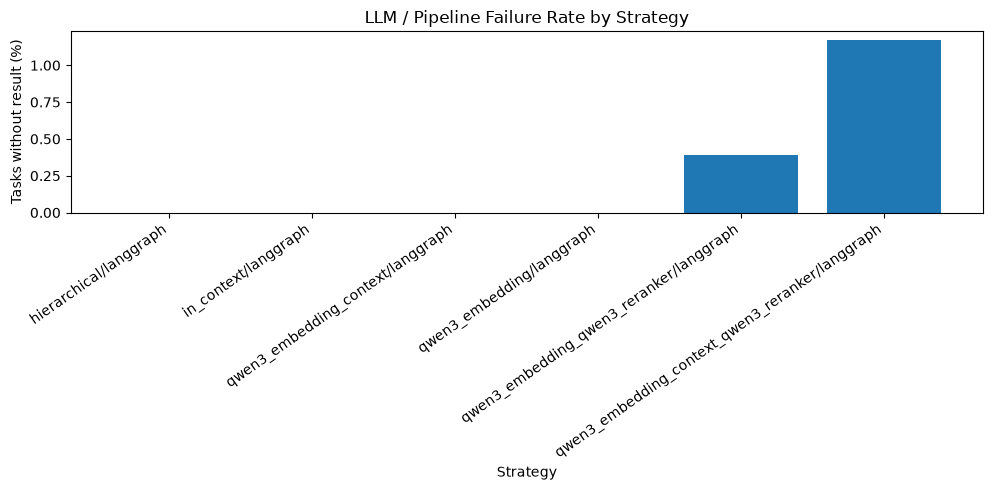

In [56]:
coverage_plot = strategy_summary.sort_values(
    "no_result_rate"
)

plt.figure(figsize=(10, 5))

plt.bar(
    coverage_plot["strategy"],
    coverage_plot["no_result_rate"] * 100
)

plt.ylabel("Tasks without result (%)")
plt.xlabel("Strategy")
plt.title("LLM / Pipeline Failure Rate by Strategy")

plt.xticks(rotation=35, ha="right")

plt.tight_layout()
plt.show()

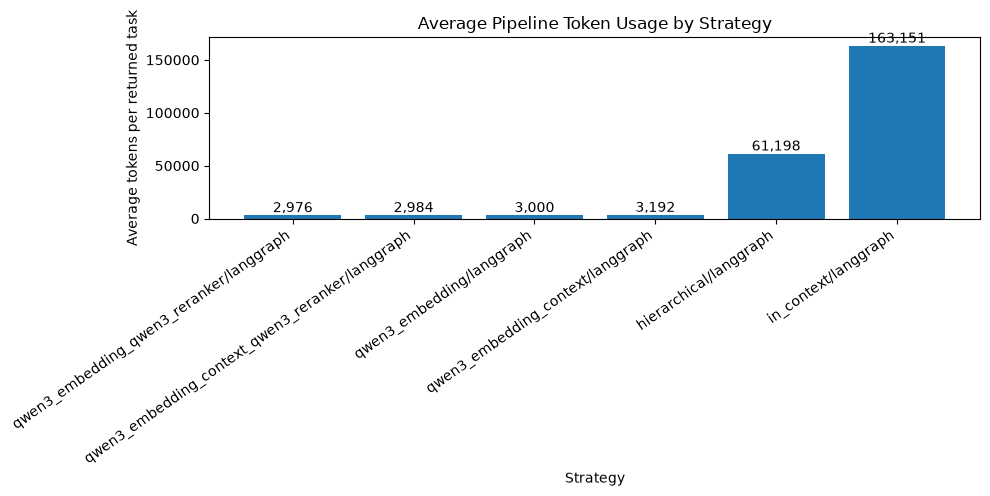

In [57]:
# ============================================================
# Average token usage
# ============================================================

token_summary = (
    task_df
    .groupby("strategy")["pipeline_total_tokens"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(10, 5))

bars = plt.bar(
    token_summary.index,
    token_summary.values
)

plt.ylabel("Average tokens per returned task")
plt.xlabel("Strategy")
plt.title("Average Pipeline Token Usage by Strategy")

plt.xticks(rotation=35, ha="right")

for bar, value in zip(bars, token_summary.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,.0f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

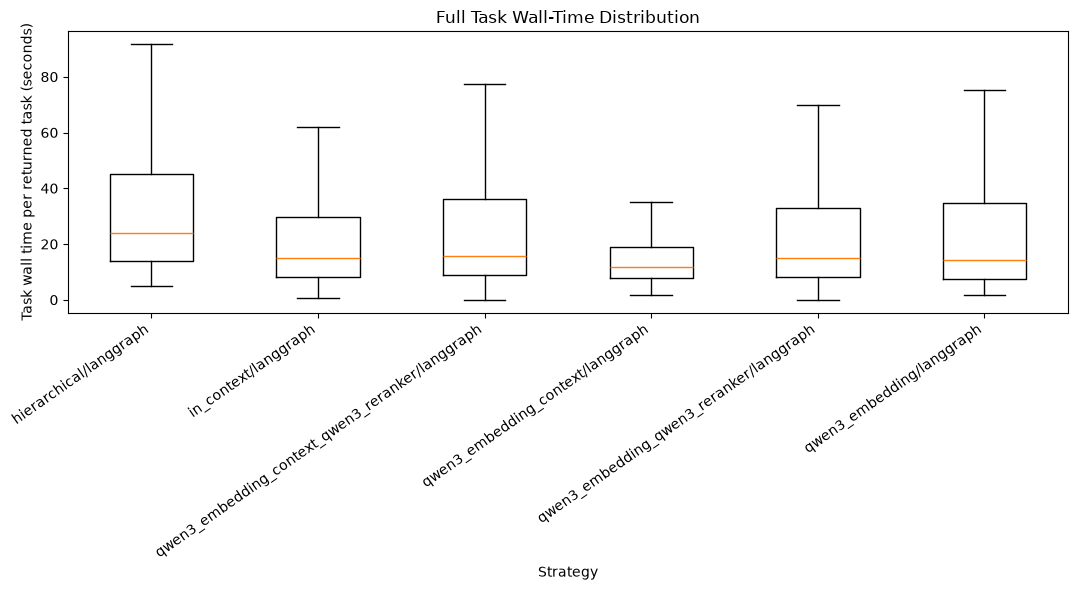

In [58]:
# ============================================================
# Full task wall-time distribution
# ============================================================

strategies = list(strategy_summary["strategy"])

latency_data = [
    task_df.loc[
        task_df["strategy"] == strategy,
        "pipeline_wall_time"
    ].dropna()
    for strategy in strategies
]

plt.figure(figsize=(11, 6))

plt.boxplot(
    latency_data,
    tick_labels=strategies,
    showfliers=False
)

plt.ylabel("Task wall time per returned task (seconds)")
plt.xlabel("Strategy")
plt.title("Full Task Wall-Time Distribution")

plt.xticks(rotation=35, ha="right")

plt.tight_layout()
plt.show()

In [59]:
# ============================================================
# Task × Strategy correctness matrix
# ============================================================

correct_matrix = task_df.pivot_table(
    index=[
        "benchmark_task_number",
        "task_id",
        "task_idx"
    ],
    columns="strategy",
    values="correct",
    aggfunc="first"
)

# Should not normally be necessary now, but protects against
# missing strategy/task combinations.
correct_matrix = correct_matrix.fillna(False).astype(bool)

print("Shape:", correct_matrix.shape)

display(correct_matrix.head())

Shape: (1024, 6)


,,strategy,hierarchical/langgraph,in_context/langgraph,qwen3_embedding/langgraph,qwen3_embedding_context/langgraph,qwen3_embedding_context_qwen3_reranker/langgraph,qwen3_embedding_qwen3_reranker/langgraph
benchmark_task_number,task_id,task_idx,,,,,,
1,wild_tool_bench_0,0,True,False,False,True,True,False
2,wild_tool_bench_0,1,True,True,False,True,True,False
3,wild_tool_bench_0,2,False,False,False,False,False,False
4,wild_tool_bench_0,3,True,True,False,True,True,False
5,wild_tool_bench_1,0,True,True,True,True,True,True


In [60]:
# ============================================================
# Number of strategies solving each task
# ============================================================

task_analysis = correct_matrix.copy()

task_analysis["num_strategies_correct"] = (
    correct_matrix.sum(axis=1)
)

task_analysis["num_strategies_failed"] = (
    len(correct_matrix.columns)
    - task_analysis["num_strategies_correct"]
)

task_analysis["solved_by_any"] = (
    task_analysis["num_strategies_correct"] > 0
)

task_analysis["solved_by_all"] = (
    task_analysis["num_strategies_correct"]
    == len(correct_matrix.columns)
)

task_analysis["failed_by_all"] = (
    task_analysis["num_strategies_correct"] == 0
)

In [61]:
difficulty_distribution = (
    task_analysis["num_strategies_correct"]
    .value_counts()
    .sort_index()
)

display(difficulty_distribution)

num_strategies_correct
0    317
1    102
2    103
3     90
4     89
5    102
6    221
Name: count, dtype: int64

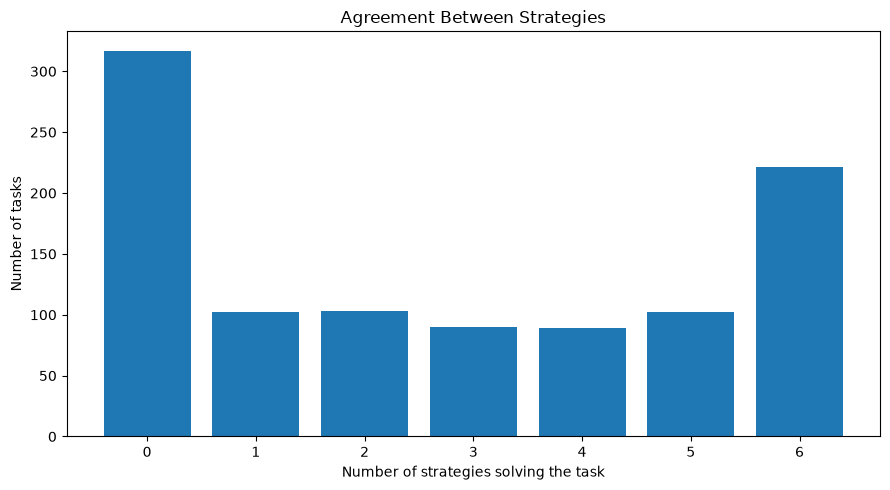

In [62]:
plt.figure(figsize=(9, 5))

plt.bar(
    difficulty_distribution.index,
    difficulty_distribution.values
)

plt.xlabel("Number of strategies solving the task")
plt.ylabel("Number of tasks")
plt.title("Agreement Between Strategies")

plt.xticks(range(len(correct_matrix.columns) + 1))

plt.tight_layout()
plt.show()

In [63]:
# ============================================================
# Overall overlap statistics
# ============================================================

n_tasks = len(task_analysis)

n_all_correct = task_analysis["solved_by_all"].sum()
n_all_failed = task_analysis["failed_by_all"].sum()
n_any_correct = task_analysis["solved_by_any"].sum()

n_exactly_one = (
    task_analysis["num_strategies_correct"] == 1
).sum()

overlap_summary = pd.DataFrame({
    "category": [
        "Solved by all strategies",
        "Solved by at least one strategy",
        "Solved by exactly one strategy",
        "Failed by all strategies",
    ],
    "tasks": [
        n_all_correct,
        n_any_correct,
        n_exactly_one,
        n_all_failed,
    ]
})

overlap_summary["rate"] = (
    overlap_summary["tasks"] / n_tasks
)

display(
    overlap_summary.style.format({
        "rate": "{:.1%}"
    })
)

,category,tasks,rate
0,Solved by all strategies,221,21.6%
1,Solved by at least one strategy,707,69.0%
2,Solved by exactly one strategy,102,10.0%
3,Failed by all strategies,317,31.0%


In [64]:
# ============================================================
# Unique wins per strategy
# ============================================================

unique_wins = {}

for strategy in correct_matrix.columns:

    strategy_correct = correct_matrix[strategy]

    other_strategies = correct_matrix.columns.drop(strategy)

    others_correct = (
        correct_matrix[other_strategies]
        .any(axis=1)
    )

    unique_mask = (
        strategy_correct
        & ~others_correct
    )

    unique_wins[strategy] = unique_mask.sum()


unique_wins_df = (
    pd.DataFrame.from_dict(
        unique_wins,
        orient="index",
        columns=["unique_wins"]
    )
    .sort_values(
        "unique_wins",
        ascending=False
    )
)

unique_wins_df

,unique_wins
hierarchical/langgraph,33
in_context/langgraph,28
qwen3_embedding_context/langgraph,16
qwen3_embedding_qwen3_reranker/langgraph,9
qwen3_embedding/langgraph,8
qwen3_embedding_context_qwen3_reranker/langgraph,8


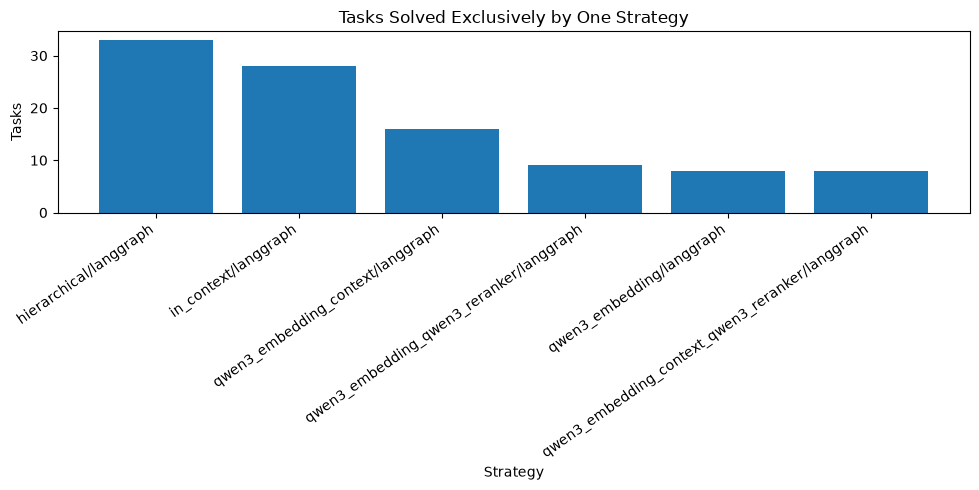

In [65]:
plt.figure(figsize=(10, 5))

plt.bar(
    unique_wins_df.index,
    unique_wins_df["unique_wins"]
)

plt.ylabel("Tasks")
plt.xlabel("Strategy")

plt.title(
    "Tasks Solved Exclusively by One Strategy"
)

plt.xticks(rotation=35, ha="right")

plt.tight_layout()
plt.show()

In [66]:
# ============================================================
# Identify unique-win tasks
# ============================================================

unique_win_rows = []

for strategy in correct_matrix.columns:

    others = correct_matrix.columns.drop(strategy)

    mask = (
        correct_matrix[strategy]
        & ~correct_matrix[others].any(axis=1)
    )

    for index in correct_matrix.index[mask]:

        benchmark_number, task_id, task_idx = index

        meta = task_metadata.get(
            (task_id, task_idx),
            {}
        )

        unique_win_rows.append({
            "strategy": strategy,
            "benchmark_task_number": benchmark_number,
            "task_id": task_id,
            "task_idx": task_idx,
            "task_type": meta.get("task_type"),
            "task_text": meta.get("task_text"),
        })


unique_win_tasks = pd.DataFrame(unique_win_rows)

display(unique_win_tasks)

,strategy,benchmark_task_number,task_id,task_idx,task_type,task_text
0,hierarchical/langgraph,13,wild_tool_bench_3,0,Single-Tool,I found a suspicious IP address 123.456.78.90....
1,hierarchical/langgraph,39,wild_tool_bench_9,2,Clarify,I want to obtain the metadata of one of them
2,hierarchical/langgraph,47,wild_tool_bench_11,2,Clarify,I'm quite interested in one of them. Please he...
3,hierarchical/langgraph,71,wild_tool_bench_17,2,Parallel Multi-Tool,Change them all to POST and simulate a respons...
4,hierarchical/langgraph,118,wild_tool_bench_29,1,Chat,"Apart from the pronunciation, could you help m..."
...,...,...,...,...,...,...
97,qwen3_embedding_qwen3_reranker/langgraph,281,wild_tool_bench_70,0,Parallel Multi-Tool,"I need to complete a task, but I'm not sure wh..."
98,qwen3_embedding_qwen3_reranker/langgraph,373,wild_tool_bench_93,0,Sequential Multi-Tool,Please provide detailed information about a sp...
99,qwen3_embedding_qwen3_reranker/langgraph,774,wild_tool_bench_193,1,Clarify,I want to query the weather data for a certain...
100,qwen3_embedding_qwen3_reranker/langgraph,775,wild_tool_bench_193,2,Clarify,What about another city?


In [67]:
display(
    unique_win_tasks.groupby(
        ["strategy", "task_type"]
    )
    .size()
    .unstack(fill_value=0)
)

task_type,Chat,Clarify,Mixed Multi-Tool,Parallel Multi-Tool,Sequential Multi-Tool,Single-Tool
strategy,,,,,,
hierarchical/langgraph,9,9,1,4,0,10
in_context/langgraph,5,3,3,6,0,11
qwen3_embedding/langgraph,3,3,1,0,0,1
qwen3_embedding_context/langgraph,3,6,0,7,0,0
qwen3_embedding_context_qwen3_reranker/langgraph,1,4,1,1,0,1
qwen3_embedding_qwen3_reranker/langgraph,0,3,0,3,1,2


In [68]:
# ============================================================
# Tasks failed by every strategy
# ============================================================

consensus_failure_mask = (
    correct_matrix.sum(axis=1) == 0
)

consensus_failure_indices = (
    correct_matrix.index[
        consensus_failure_mask
    ]
)

consensus_failure_rows = []

for index in consensus_failure_indices:

    benchmark_number, task_id, task_idx = index

    meta = task_metadata.get(
        (task_id, task_idx),
        {}
    )

    consensus_failure_rows.append({
        "benchmark_task_number": benchmark_number,
        "task_id": task_id,
        "task_idx": task_idx,
        "task_type": meta.get("task_type"),
        "task_text": meta.get("task_text"),
    })


consensus_failures = pd.DataFrame(
    consensus_failure_rows
)

print(
    f"{len(consensus_failures)} / {len(correct_matrix)} "
    f"tasks failed by every strategy "
    f"({len(consensus_failures) / len(correct_matrix):.1%})"
)

display(consensus_failures.head(20))

317 / 1024 tasks failed by every strategy (31.0%)


,benchmark_task_number,task_id,task_idx,task_type,task_text
0,3,wild_tool_bench_0,2,Mixed Multi-Tool,"Check the air quality as well. If it's good, t..."
1,8,wild_tool_bench_1,3,Clarify,I want to know what courses related to one of ...
2,10,wild_tool_bench_2,1,Single-Tool,Create another new transaction record with an ...
3,15,wild_tool_bench_3,2,Clarify,I have a visitor who is from one of the above ...
4,19,wild_tool_bench_4,2,Parallel Multi-Tool,"Okay, I've been researching users these days. ..."
5,20,wild_tool_bench_4,3,Clarify,I need to set up two-factor authentication for...
6,32,wild_tool_bench_7,3,Parallel Multi-Tool,I also want to know the information about an e...
7,35,wild_tool_bench_8,2,Clarify,Mark one more for me
8,40,wild_tool_bench_9,3,Mixed Multi-Tool,Get the content of the other articles above fo...
9,52,wild_tool_bench_12,3,Mixed Multi-Tool,Which countries' sports-related datasets were ...


In [69]:
# ============================================================
# Consensus failures by task type
# ============================================================

all_task_types = (
    task_df[
        [
            "benchmark_task_number",
            "task_type"
        ]
    ]
    .drop_duplicates()
    ["task_type"]
    .value_counts()
)

failure_types = (
    consensus_failures["task_type"]
    .value_counts()
)

failure_type_analysis = pd.DataFrame({
    "total_tasks": all_task_types,
    "consensus_failures": failure_types
}).fillna(0)

failure_type_analysis["failure_rate"] = (
    failure_type_analysis["consensus_failures"]
    / failure_type_analysis["total_tasks"]
)

failure_type_analysis = (
    failure_type_analysis
    .sort_values(
        "failure_rate",
        ascending=False
    )
)

display(
    failure_type_analysis.style.format({
        "failure_rate": "{:.1%}"
    })
)

,total_tasks,consensus_failures,failure_rate
task_type,,,
Mixed Multi-Tool,84,62,73.8%
Sequential Multi-Tool,16,9,56.2%
Clarify,256,119,46.5%
Parallel Multi-Tool,156,61,39.1%
Single-Tool,256,52,20.3%
Chat,256,14,5.5%


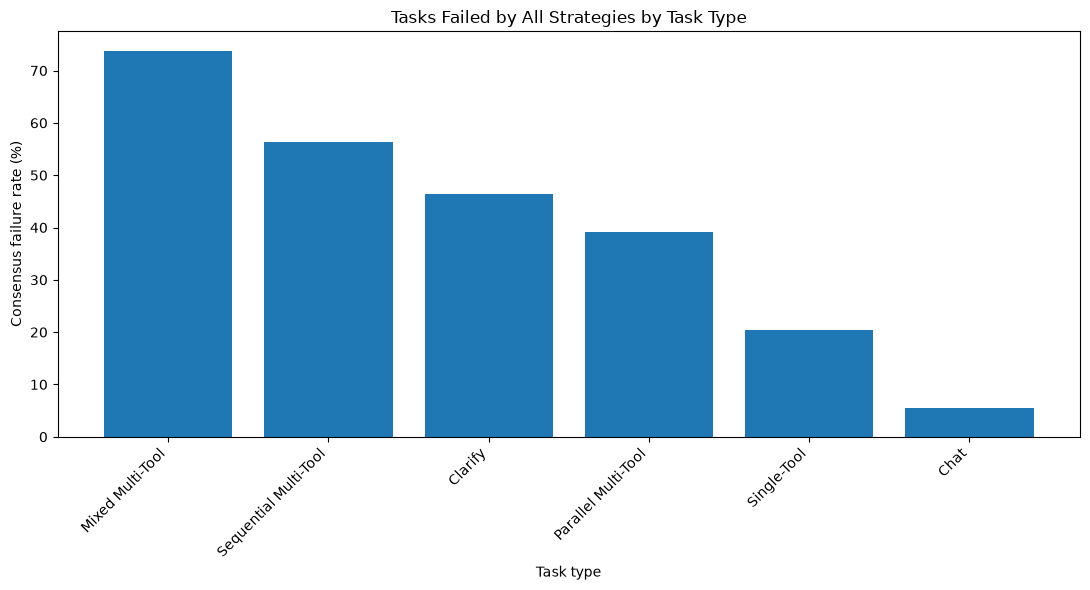

In [70]:
plt.figure(figsize=(11, 6))

plt.bar(
    failure_type_analysis.index,
    failure_type_analysis["failure_rate"] * 100
)

plt.ylabel("Consensus failure rate (%)")
plt.xlabel("Task type")

plt.title(
    "Tasks Failed by All Strategies by Task Type"
)

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [71]:
# ============================================================
# Pairwise Jaccard similarity of solved tasks
# ============================================================

strategies = list(correct_matrix.columns)

jaccard = pd.DataFrame(
    index=strategies,
    columns=strategies,
    dtype=float
)

for strategy_a in strategies:

    for strategy_b in strategies:

        a = correct_matrix[strategy_a]
        b = correct_matrix[strategy_b]

        intersection = (a & b).sum()
        union = (a | b).sum()

        jaccard.loc[
            strategy_a,
            strategy_b
        ] = (
            intersection / union
            if union > 0
            else np.nan
        )


display(
    jaccard.style.format("{:.3f}")
)

,hierarchical/langgraph,in_context/langgraph,qwen3_embedding/langgraph,qwen3_embedding_context/langgraph,qwen3_embedding_context_qwen3_reranker/langgraph,qwen3_embedding_qwen3_reranker/langgraph
hierarchical/langgraph,1.000,0.645,0.575,0.575,0.633,0.606
in_context/langgraph,0.645,1.000,0.595,0.573,0.599,0.603
qwen3_embedding/langgraph,0.575,0.595,1.000,0.555,0.612,0.712
qwen3_embedding_context/langgraph,0.575,0.573,0.555,1.000,0.647,0.570
qwen3_embedding_context_qwen3_reranker/langgraph,0.633,0.599,0.612,0.647,1.000,0.648
qwen3_embedding_qwen3_reranker/langgraph,0.606,0.603,0.712,0.570,0.648,1.000


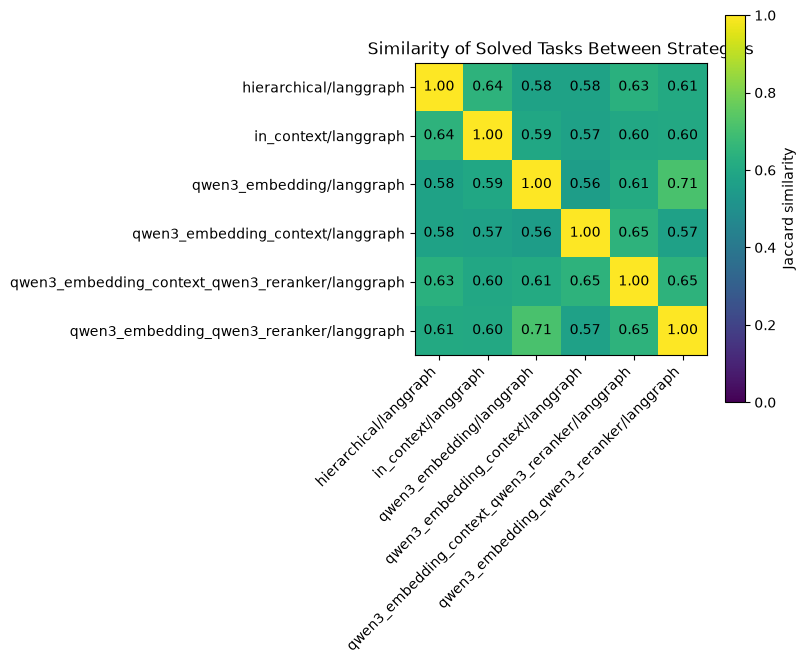

In [72]:
# ============================================================
# Jaccard similarity heatmap
# ============================================================

fig, ax = plt.subplots(
    figsize=(8, 7)
)

image = ax.imshow(
    jaccard.values,
    vmin=0,
    vmax=1
)

ax.set_xticks(
    range(len(strategies))
)

ax.set_yticks(
    range(len(strategies))
)

ax.set_xticklabels(
    strategies,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(
    strategies
)

for i in range(len(strategies)):
    for j in range(len(strategies)):

        ax.text(
            j,
            i,
            f"{jaccard.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.colorbar(
    image,
    label="Jaccard similarity"
)

plt.title(
    "Similarity of Solved Tasks Between Strategies"
)

plt.tight_layout()
plt.show()

In [73]:
# ============================================================
# Build selection-level dataframe
# ============================================================

selection_rows_all = []

for strategy, files in runs.items():

    selection_file = files.get("selection")

    if selection_file is None or not selection_file.exists():
        continue

    selection_rows = read_jsonl(selection_file)

    for row in selection_rows:

        selected = safe_float(
            row.get("selected_tools_count")
        )

        available = safe_float(
            row.get("available_tools_count")
        )

        reduction = None

        if (
            selected is not None
            and available is not None
            and available > 0
        ):
            reduction = 1 - selected / available

        selection_rows_all.append({
            "strategy": strategy,

            "task_id": str(
                row.get("test_entry_id", "")
            ),

            "task_idx": row.get("task_idx"),

            "selected_tools":
                selected,

            "available_tools":
                available,

            "selection_reduction":
                reduction,

            "zero_selected":
                selected == 0
                if selected is not None
                else False,
        })


selection_df = pd.DataFrame(
    selection_rows_all
)

print(selection_df.shape)

display(selection_df.head())

(16919, 7)


,strategy,task_id,task_idx,selected_tools,available_tools,selection_reduction,zero_selected
0,hierarchical/langgraph,wild_tool_bench_0,0,1.0,1283.0,0.999221,False
1,hierarchical/langgraph,wild_tool_bench_0,0,10.0,1283.0,0.992206,False
2,hierarchical/langgraph,wild_tool_bench_0,1,10.0,1283.0,0.992206,False
3,hierarchical/langgraph,wild_tool_bench_0,1,10.0,1283.0,0.992206,False
4,hierarchical/langgraph,wild_tool_bench_0,2,2.0,1283.0,0.998441,False


In [74]:
# ============================================================
# Selection summary
# ============================================================

selection_summary = (
    selection_df
    .groupby("strategy")
    .agg(
        selection_calls=(
            "selected_tools",
            "size"
        ),

        avg_selected_tools=(
            "selected_tools",
            "mean"
        ),

        median_selected_tools=(
            "selected_tools",
            "median"
        ),

        avg_available_tools=(
            "available_tools",
            "mean"
        ),

        avg_reduction=(
            "selection_reduction",
            "mean"
        ),

        zero_selections=(
            "zero_selected",
            "sum"
        ),
    )
    .reset_index()
)

selection_summary["zero_selection_rate"] = (
    selection_summary["zero_selections"]
    / selection_summary["selection_calls"]
)

display(
    selection_summary.style.format({
        "avg_selected_tools": "{:.1f}",
        "median_selected_tools": "{:.1f}",
        "avg_available_tools": "{:.1f}",
        "avg_reduction": "{:.1%}",
        "zero_selection_rate": "{:.1%}",
    })
)

,strategy,selection_calls,avg_selected_tools,median_selected_tools,avg_available_tools,avg_reduction,zero_selections,zero_selection_rate
0,hierarchical/langgraph,2107,5.5,4.0,1283.0,99.6%,12,0.6%
1,in_context/langgraph,1771,1283.0,1283.0,1283.0,0.0%,0,0.0%
2,qwen3_embedding/langgraph,3361,5.0,5.0,1283.0,99.6%,0,0.0%
3,qwen3_embedding_context/langgraph,2462,5.0,5.0,1283.0,99.6%,0,0.0%
4,qwen3_embedding_context_qwen3_reranker/langgraph,3676,12.5,12.5,643.9,40.2%,0,0.0%
5,qwen3_embedding_qwen3_reranker/langgraph,3542,12.5,12.5,644.0,40.5%,0,0.0%


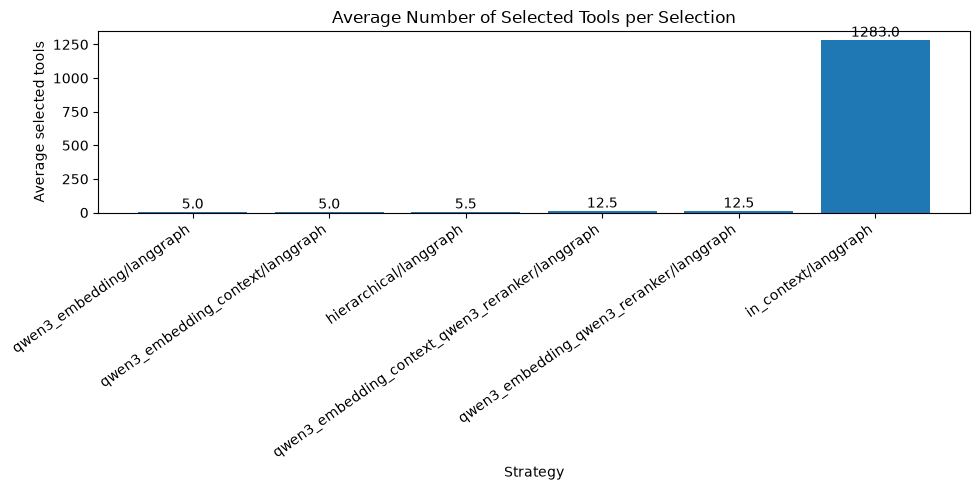

In [75]:
plot_df = (
    selection_summary
    .sort_values("avg_selected_tools")
)

plt.figure(figsize=(10, 5))

bars = plt.bar(
    plot_df["strategy"],
    plot_df["avg_selected_tools"]
)

plt.ylabel("Average selected tools")
plt.xlabel("Strategy")
plt.title("Average Number of Selected Tools per Selection")

plt.xticks(rotation=35, ha="right")

for bar, value in zip(
    bars,
    plot_df["avg_selected_tools"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [76]:
# ============================================================
# Aggregate selection information per task
# ============================================================

selection_per_task = (
    selection_df
    .groupby(
        ["strategy", "task_id", "task_idx"]
    )
    .agg(
        avg_selected_tools=(
            "selected_tools",
            "mean"
        ),

        max_selected_tools=(
            "selected_tools",
            "max"
        ),

        avg_available_tools=(
            "available_tools",
            "mean"
        ),

        avg_selection_reduction=(
            "selection_reduction",
            "mean"
        ),

        num_selection_calls=(
            "selected_tools",
            "size"
        ),
    )
    .reset_index()
)

In [77]:
selection_task_df = task_df.merge(
    selection_per_task,
    on=[
        "strategy",
        "task_id",
        "task_idx"
    ],
    how="left"
)

In [78]:
selected_vs_correct = (
    selection_task_df
    .dropna(subset=["avg_selected_tools"])
    .groupby(
        ["strategy", "correct"]
    )
    ["avg_selected_tools"]
    .mean()
    .unstack()
)

selected_vs_correct.columns = [
    "incorrect",
    "correct"
]

display(selected_vs_correct)

,incorrect,correct
strategy,,
hierarchical/langgraph,6.081402,5.440142
in_context/langgraph,1283.000000,1283.000000
qwen3_embedding/langgraph,5.000000,5.000000
qwen3_embedding_context/langgraph,5.000000,5.000000
qwen3_embedding_context_qwen3_reranker/langgraph,12.500000,12.500000
qwen3_embedding_qwen3_reranker/langgraph,12.500000,12.500000


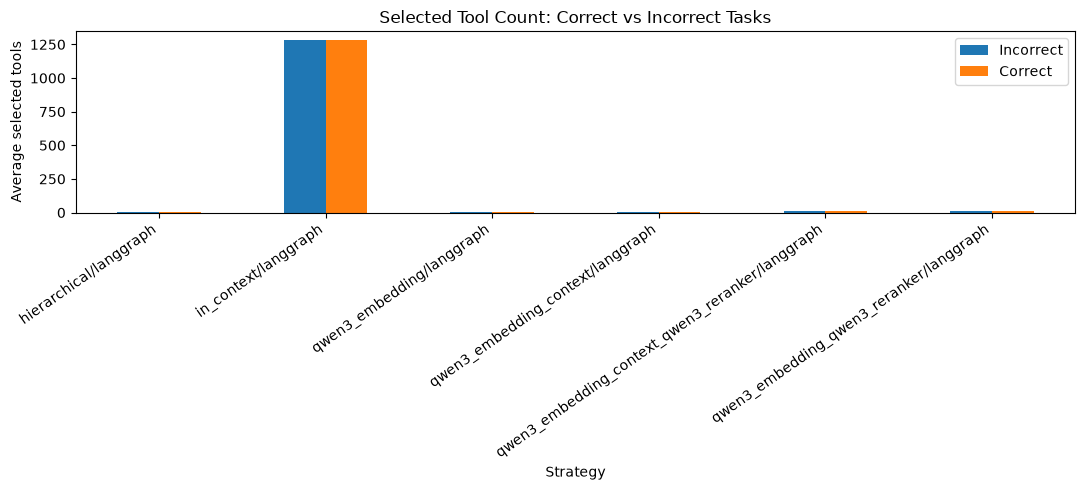

In [79]:
selected_vs_correct.plot(
    kind="bar",
    figsize=(11, 5)
)

plt.ylabel("Average selected tools")
plt.xlabel("Strategy")
plt.title("Selected Tool Count: Correct vs Incorrect Tasks")

plt.xticks(rotation=35, ha="right")

plt.legend([
    "Incorrect",
    "Correct"
])

plt.tight_layout()
plt.show()

In [80]:
selected_vs_optimal = (
    selection_task_df
    .dropna(subset=["avg_selected_tools"])
    .groupby(
        ["strategy", "optimal"]
    )
    ["avg_selected_tools"]
    .mean()
    .unstack()
)

selected_vs_optimal.columns = [
    "not_optimal",
    "optimal"
]

display(selected_vs_optimal)

,not_optimal,optimal
strategy,,
hierarchical/langgraph,5.936626,5.544422
in_context/langgraph,1283.000000,1283.000000
qwen3_embedding/langgraph,5.000000,5.000000
qwen3_embedding_context/langgraph,5.000000,5.000000
qwen3_embedding_context_qwen3_reranker/langgraph,12.500000,12.500000
qwen3_embedding_qwen3_reranker/langgraph,12.500000,12.500000


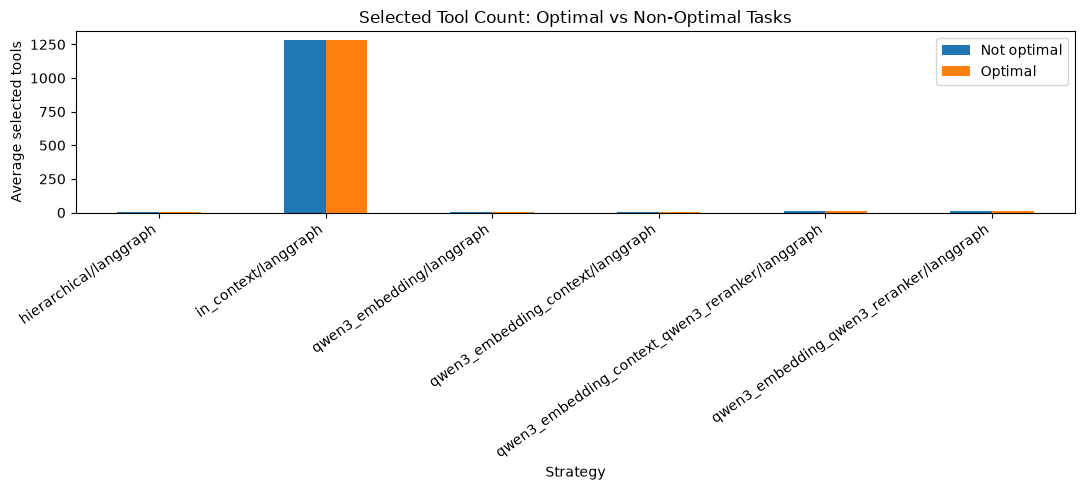

In [81]:
selected_vs_optimal.plot(
    kind="bar",
    figsize=(11, 5)
)

plt.ylabel("Average selected tools")
plt.xlabel("Strategy")
plt.title("Selected Tool Count: Optimal vs Non-Optimal Tasks")

plt.xticks(rotation=35, ha="right")

plt.legend([
    "Not optimal",
    "Optimal"
])

plt.tight_layout()
plt.show()

In [82]:
selection_task_df["selection_size_bucket"] = pd.cut(
    selection_task_df["avg_selected_tools"],
    bins=[
        0,
        5,
        10,
        20,
        50,
        100,
        float("inf")
    ],
    labels=[
        "1–5",
        "6–10",
        "11–20",
        "21–50",
        "51–100",
        "100+"
    ],
    include_lowest=True
)

In [83]:
bucket_performance = (
    selection_task_df
    .dropna(subset=["selection_size_bucket"])
    .groupby(
        ["strategy", "selection_size_bucket"],
        observed=True
    )
    .agg(
        tasks=("correct", "size"),
        correct_rate=("correct", "mean"),
        optimal_rate=("optimal", "mean"),
        avg_pipeline_tokens=(
            "pipeline_total_tokens",
            "mean"
        ),
    )
    .reset_index()
)

bucket_accuracy = bucket_performance.assign(
    accuracy_pct=bucket_performance["correct_rate"] * 100
)

display(bucket_performance)

,strategy,selection_size_bucket,tasks,correct_rate,optimal_rate,avg_pipeline_tokens
0,hierarchical/langgraph,1–5,496,0.534274,0.461694,62110.054435
1,hierarchical/langgraph,6–10,522,0.454023,0.413793,60942.978927
2,in_context/langgraph,100+,999,0.488488,0.424424,159722.018018
3,qwen3_embedding/langgraph,1–5,1024,0.416992,0.364258,3000.159180
4,qwen3_embedding_context/langgraph,1–5,1024,0.419922,0.395508,3192.074219
5,qwen3_embedding_context_qwen3_reranker/langgraph,11–20,1018,0.470530,0.409627,3001.222004
6,qwen3_embedding_qwen3_reranker/langgraph,11–20,1023,0.419355,0.364614,2978.774194


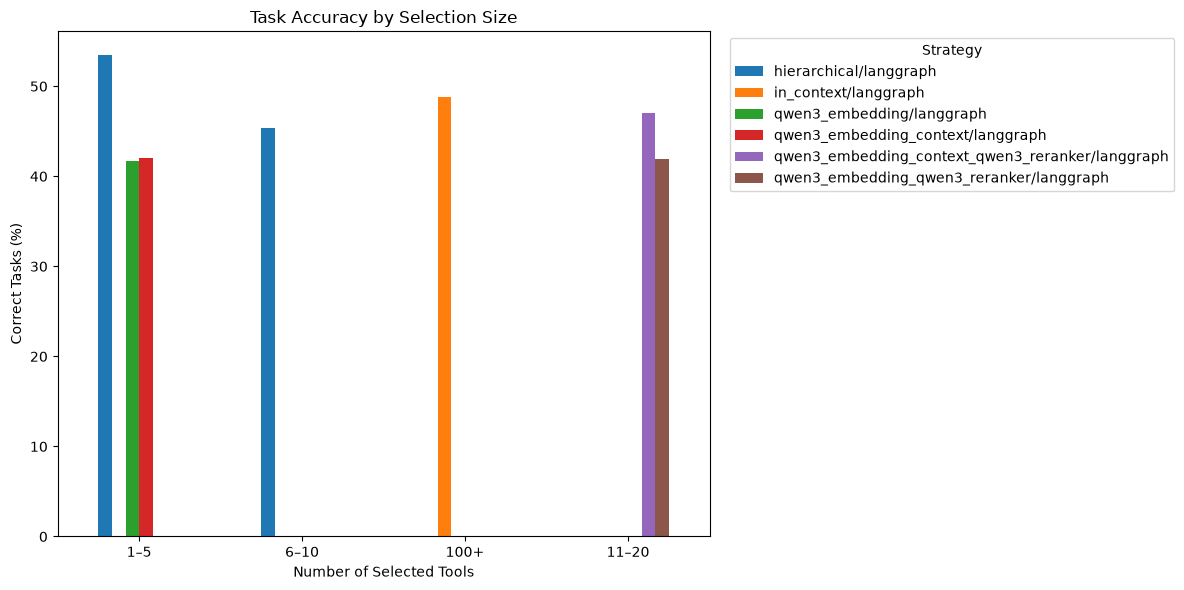

In [84]:
# ============================================================
# Plot: Accuracy by selected tool count
# ============================================================

accuracy_pivot = bucket_accuracy.pivot(
    index="selection_size_bucket",
    columns="strategy",
    values="accuracy_pct"
)

accuracy_pivot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.xlabel("Number of Selected Tools")
plt.ylabel("Correct Tasks (%)")
plt.title("Task Accuracy by Selection Size")

plt.xticks(rotation=0)

plt.legend(
    title="Strategy",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

# Section: Official `eval_runner.py` Scoring (`score/` directory)

The cells above analyze the raw `result/` folder with a hand-rolled accuracy
calculation. The cells below instead load the **official** metrics produced by
`wtb/eval_runner.py` (the `Wild-Tool-Bench_metric.json` files under `score/`),
which is the same scoring logic used for the leaderboard (task/session
accuracy, per task-type accuracy, and the optimal-tool-selection rate).

In [85]:
# ============================================================
# Discover all official score runs (produced by eval_runner.py)
# ============================================================

SCORE_ROOT = PROJECT_ROOT / "score"


def read_json(path: Path):
    """Read a single JSON object from disk, or None if missing."""

    if not path.exists():
        return None

    with open(path, encoding="utf-8") as f:
        return json.load(f)


def discover_score_runs(score_root: Path):
    """
    Discover every scored strategy under `score/`.

    Returns
    -------
    dict

    {
        "20B_in_context/langgraph": {
            "metric": Path(...),
            "score": Path(...),
        },
        ...
    }
    """

    runs = {}

    if not score_root.exists():
        return runs

    for metric_file in sorted(score_root.rglob("Wild-Tool-Bench_metric.json")):

        run_name = metric_file.parent.relative_to(score_root).as_posix()

        runs[run_name] = {
            "metric": metric_file,
            "score": metric_file.with_name("Wild-Tool-Bench_score.jsonl"),
        }

    return runs


score_runs = discover_score_runs(SCORE_ROOT)

print(f"Found {len(score_runs)} scored strategies under {SCORE_ROOT}\n")

for name, files in score_runs.items():
    print("=" * 60)
    print(name)

    for key, path in files.items():
        print(f"  {key:<10} {path.exists()}   {path}")


Found 15 scored strategies under /home/aherrman/ToolSelectionBenchmark/wild-tool-bench/score

120B_embedding/langgraph
  metric     True   /home/aherrman/ToolSelectionBenchmark/wild-tool-bench/score/120B_embedding/langgraph/Wild-Tool-Bench_metric.json
  score      True   /home/aherrman/ToolSelectionBenchmark/wild-tool-bench/score/120B_embedding/langgraph/Wild-Tool-Bench_score.jsonl
120B_embedding_context/langgraph
  metric     True   /home/aherrman/ToolSelectionBenchmark/wild-tool-bench/score/120B_embedding_context/langgraph/Wild-Tool-Bench_metric.json
  score      True   /home/aherrman/ToolSelectionBenchmark/wild-tool-bench/score/120B_embedding_context/langgraph/Wild-Tool-Bench_score.jsonl
120B_hierarchical/langgraph
  metric     True   /home/aherrman/ToolSelectionBenchmark/wild-tool-bench/score/120B_hierarchical/langgraph/Wild-Tool-Bench_metric.json
  score      True   /home/aherrman/ToolSelectionBenchmark/wild-tool-bench/score/120B_hierarchical/langgraph/Wild-Tool-Bench_score.jsonl


In [86]:
# ============================================================
# Load official metric.json files and build a summary table
# ============================================================

TASK_TYPES = [
    "Single-Tool",
    "Multi-Tool",
    "Parallel Multi-Tool",
    "Sequential Multi-Tool",
    "Mixed Multi-Tool",
    "Clarify",
    "Chat",
]

score_metrics = {}

score_summary_rows = []

for run_name, files in score_runs.items():

    metric = read_json(files["metric"])

    if metric is None:
        continue

    score_metrics[run_name] = metric

    total_info = metric.get("total_info", {}) or {}
    task_info = total_info.get("task", {}) or {}
    session_info = total_info.get("session", {}) or {}

    optimal_info = metric.get("optimal_info", {}) or {}
    optimal_total = optimal_info.get("Total", {}) or {}

    row = {
        "strategy": run_name,
        "task_accuracy": task_info.get("accuracy"),
        "task_correct": task_info.get("correct_count"),
        "task_total": task_info.get("total_count"),
        "session_accuracy": session_info.get("accuracy"),
        "session_correct": session_info.get("correct_count"),
        "session_total": session_info.get("total_count"),
        "optimal_rate": optimal_total.get("accuracy"),
        "optimal_correct": optimal_total.get("correct_count"),
        "optimal_total": optimal_total.get("total_count"),
    }

    task_type_info = metric.get("task_type_info", {}) or {}

    for task_type in TASK_TYPES:
        stats = task_type_info.get(task_type, {}) or {}
        row[f"acc__{task_type}"] = stats.get("accuracy")

    score_summary_rows.append(row)

score_summary = pd.DataFrame(score_summary_rows)


def safe_ratio(numer, denom):
    if pd.isna(numer) or pd.isna(denom) or denom in (None, 0):
        return np.nan
    return numer / denom


score_summary["task_accuracy_from_counts"] = score_summary.apply(
    lambda r: safe_ratio(r["task_correct"], r["task_total"]),
    axis=1,
)

score_summary["session_accuracy_from_counts"] = score_summary.apply(
    lambda r: safe_ratio(r["session_correct"], r["session_total"]),
    axis=1,
)

score_summary["optimal_rate_from_counts"] = score_summary.apply(
    lambda r: safe_ratio(r["optimal_correct"], r["optimal_total"]),
    axis=1,
)

score_summary["task_accuracy"] = score_summary["task_accuracy_from_counts"]
score_summary["session_accuracy"] = score_summary["session_accuracy_from_counts"]
score_summary["optimal_rate"] = score_summary["optimal_rate_from_counts"]

score_summary = score_summary.sort_values("task_accuracy", ascending=False)

score_summary[
    [
        "strategy",
        "task_correct",
        "task_total",
        "task_accuracy",
        "optimal_correct",
        "optimal_total",
        "optimal_rate",
    ]
].head()


,strategy,task_correct,task_total,task_accuracy,optimal_correct,optimal_total,optimal_rate
2,120B_hierarchical/langgraph,373,1024,0.364258,0,240,0.0000
3,120B_in_context/langgraph,371,1024,0.362305,0,240,0.0000
1,120B_embedding_context/langgraph,367,1024,0.358398,0,240,0.0000
5,120B_reranker_context/langgraph,360,1024,0.351562,0,240,0.0000
10,20B_embedding_context/langgraph,340,1024,0.332031,3,240,0.0125


In [87]:
# ============================================================
# Build Task x Strategy correctness matrix from official score
# ============================================================


def read_jsonl(path: Path):
    if not path.exists():
        return []
    rows = []
    with open(path, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            rows.append(json.loads(line))
    return rows


score_task_rows = []

for strategy, files in score_runs.items():

    score_file = files.get("score")

    if score_file is None or not score_file.exists():
        continue

    session_rows = read_jsonl(score_file)

    for session_pos, session in enumerate(session_rows):

        session_id = str(session.get("id", f"session_{session_pos}"))
        results = session.get("results", []) or []

        for turn_idx, result in enumerate(results):
            label = result.get("label", "error")

            score_task_rows.append({
                "strategy": strategy,
                "session_id": session_id,
                "turn_idx": turn_idx,
                "task_ref": f"{session_id}[{turn_idx}]",
                "correct": label == "correct",
                "is_optimal": bool(result.get("is_optimal", False)),
            })


score_task_df = pd.DataFrame(score_task_rows)

if score_task_df.empty:
    raise ValueError("No score rows found. Check score_runs and score files.")


score_correct_matrix = (
    score_task_df
    .pivot_table(
        index="task_ref",
        columns="strategy",
        values="correct",
        aggfunc="max",
        fill_value=False,
    )
    .astype(bool)
)

score_optimal_matrix = (
    score_task_df
    .pivot_table(
        index="task_ref",
        columns="strategy",
        values="is_optimal",
        aggfunc="max",
        fill_value=False,
    )
    .astype(bool)
)

print("score_task_df shape:", score_task_df.shape)
print("score_correct_matrix shape:", score_correct_matrix.shape)

matrix_correct_counts = (
    score_correct_matrix
    .sum(axis=0)
    .rename("matrix_task_correct")
    .rename_axis("strategy")
    .reset_index()
)

score_count_check = (
    score_summary[["strategy", "task_correct", "task_total", "task_accuracy"]]
    .merge(matrix_correct_counts, on="strategy", how="left")
)

score_count_check["correct_delta"] = (
    score_count_check["matrix_task_correct"] - score_count_check["task_correct"]
)

display(score_count_check.sort_values("correct_delta", ascending=False))

display(score_correct_matrix.head())

score_task_df shape: (14988, 6)
score_correct_matrix shape: (1024, 15)


,strategy,task_correct,task_total,task_accuracy,matrix_task_correct,correct_delta
0,120B_hierarchical/langgraph,373,1024,0.364258,373,0
1,120B_in_context/langgraph,371,1024,0.362305,371,0
2,120B_embedding_context/langgraph,367,1024,0.358398,367,0
3,120B_reranker_context/langgraph,360,1024,0.351562,360,0
4,20B_embedding_context/langgraph,340,1024,0.332031,340,0
5,20B_embedding_reranker_context/langgraph,339,1024,0.331055,339,0
6,120B_embedding/langgraph,327,1024,0.319336,327,0
7,20B_hierarchical/langgraph,327,1024,0.319336,327,0
8,120B_reranker/langgraph,314,1024,0.306641,314,0
9,120B_v2_embedding_context/langgraph,196,656,0.298780,196,0


strategy,120B_embedding/langgraph,120B_embedding_context/langgraph,120B_hierarchical/langgraph,120B_in_context/langgraph,120B_reranker/langgraph,120B_reranker_context/langgraph,120B_v2_embedding_context/langgraph,120B_v2_hierarchical/langgraph,120B_v2_in_context/langgraph,20B_embedding/langgraph,20B_embedding_context/langgraph,20B_embedding_reranker/langgraph,20B_embedding_reranker_context/langgraph,20B_hierarchical/langgraph,20B_in_context/langgraph
task_ref,,,,,,,,,,,,,,,
wild_tool_bench_0[0],False,False,False,True,False,False,False,False,False,False,False,True,True,True,False
wild_tool_bench_0[1],True,True,True,True,False,True,False,True,True,False,True,False,True,True,True
wild_tool_bench_0[2],False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
wild_tool_bench_0[3],True,True,False,True,True,True,True,True,False,True,True,False,True,True,True
wild_tool_bench_100[0],False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


,unique_wins
20B_in_context/langgraph,9
20B_hierarchical/langgraph,8
120B_in_context/langgraph,7
20B_embedding_reranker/langgraph,7
20B_embedding_reranker_context/langgraph,7
20B_embedding_context/langgraph,6
120B_hierarchical/langgraph,4
120B_v2_in_context/langgraph,3
120B_embedding/langgraph,2
120B_embedding_context/langgraph,2


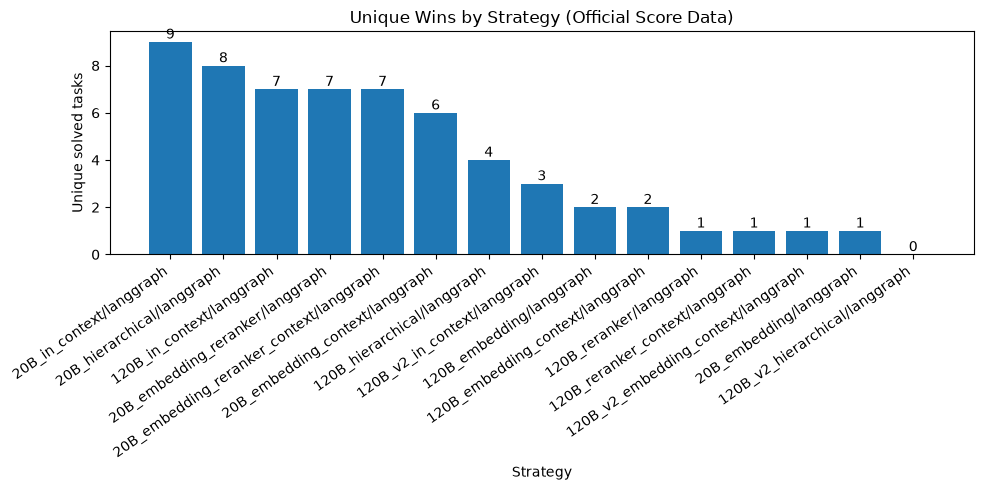

In [88]:
# ============================================================
# Unique wins from official score correctness matrix
# ============================================================

score_unique_wins = {}

for strategy in score_correct_matrix.columns:

    strategy_correct = score_correct_matrix[strategy]
    other_strategies = score_correct_matrix.columns.drop(strategy)

    others_correct = score_correct_matrix[other_strategies].any(axis=1)

    unique_mask = strategy_correct & ~others_correct
    score_unique_wins[strategy] = int(unique_mask.sum())


score_unique_wins_df = (
    pd.DataFrame.from_dict(
        score_unique_wins,
        orient="index",
        columns=["unique_wins"]
    )
    .sort_values("unique_wins", ascending=False)
)

display(score_unique_wins_df)

plt.figure(figsize=(10, 5))

bars = plt.bar(
    score_unique_wins_df.index,
    score_unique_wins_df["unique_wins"]
)

plt.ylabel("Unique solved tasks")
plt.xlabel("Strategy")
plt.title("Unique Wins by Strategy (Official Score Data)")

plt.xticks(rotation=35, ha="right")

for bar, value in zip(bars, score_unique_wins_df["unique_wins"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(value)}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

,120B_embedding/langgraph,120B_embedding_context/langgraph,120B_hierarchical/langgraph,120B_in_context/langgraph,120B_reranker/langgraph,120B_reranker_context/langgraph,120B_v2_embedding_context/langgraph,120B_v2_hierarchical/langgraph,120B_v2_in_context/langgraph,20B_embedding/langgraph,20B_embedding_context/langgraph,20B_embedding_reranker/langgraph,20B_embedding_reranker_context/langgraph,20B_hierarchical/langgraph,20B_in_context/langgraph
120B_embedding/langgraph,1.000,0.709,0.699,0.670,0.732,0.709,0.387,0.642,0.606,0.554,0.558,0.558,0.556,0.553,0.498
120B_embedding_context/langgraph,0.709,1.000,0.721,0.704,0.686,0.756,0.462,0.639,0.605,0.521,0.600,0.511,0.583,0.577,0.517
120B_hierarchical/langgraph,0.699,0.721,1.000,0.730,0.680,0.758,0.412,0.626,0.624,0.553,0.581,0.539,0.568,0.570,0.528
120B_in_context/langgraph,0.670,0.704,0.730,1.000,0.667,0.736,0.386,0.590,0.650,0.527,0.563,0.517,0.543,0.551,0.541
120B_reranker/langgraph,0.732,0.686,0.680,0.667,1.000,0.706,0.375,0.638,0.609,0.565,0.542,0.569,0.536,0.556,0.499
120B_reranker_context/langgraph,0.709,0.756,0.758,0.736,0.706,1.000,0.418,0.638,0.620,0.533,0.602,0.537,0.596,0.576,0.526
120B_v2_embedding_context/langgraph,0.387,0.462,0.412,0.386,0.375,0.418,1.000,0.398,0.340,0.338,0.399,0.336,0.372,0.348,0.304
120B_v2_hierarchical/langgraph,0.642,0.639,0.626,0.590,0.638,0.638,0.398,1.000,0.615,0.556,0.588,0.544,0.554,0.678,0.539
120B_v2_in_context/langgraph,0.606,0.605,0.624,0.650,0.609,0.620,0.340,0.615,1.000,0.527,0.548,0.520,0.531,0.570,0.584
20B_embedding/langgraph,0.554,0.521,0.553,0.527,0.565,0.533,0.338,0.556,0.527,1.000,0.646,0.690,0.618,0.587,0.543


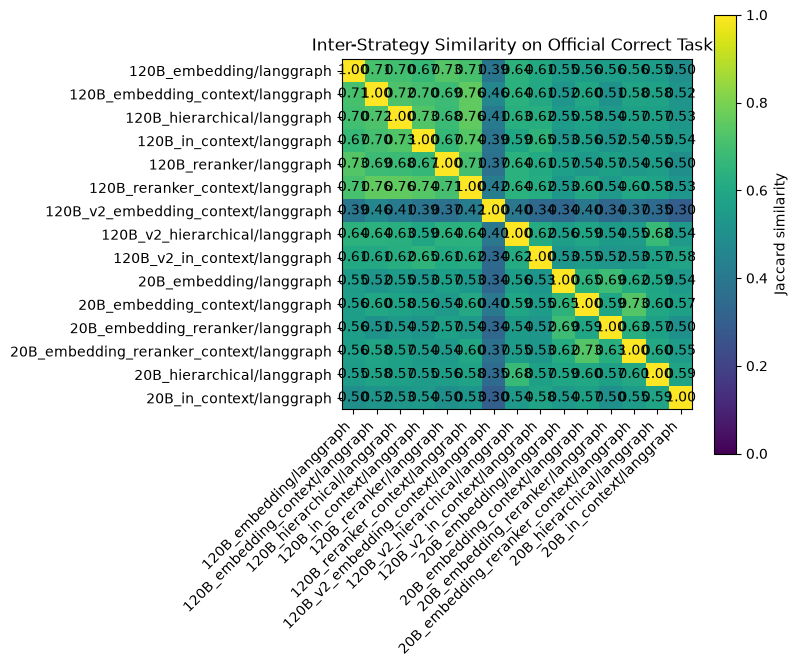

In [89]:
# ============================================================
# Inter-strategy similarity (Jaccard) from official score matrix
# ============================================================

score_strategies = list(score_correct_matrix.columns)

score_jaccard = pd.DataFrame(
    index=score_strategies,
    columns=score_strategies,
    dtype=float,
)

for strategy_a in score_strategies:

    for strategy_b in score_strategies:

        a = score_correct_matrix[strategy_a]
        b = score_correct_matrix[strategy_b]

        intersection = (a & b).sum()
        union = (a | b).sum()

        score_jaccard.loc[strategy_a, strategy_b] = (
            intersection / union
            if union > 0
            else np.nan
        )


display(score_jaccard.style.format("{:.3f}"))

fig, ax = plt.subplots(figsize=(8, 7))

image = ax.imshow(
    score_jaccard.values,
    vmin=0,
    vmax=1,
)

ax.set_xticks(range(len(score_strategies)))
ax.set_yticks(range(len(score_strategies)))

ax.set_xticklabels(
    score_strategies,
    rotation=45,
    ha="right",
)
ax.set_yticklabels(score_strategies)

for i in range(len(score_strategies)):
    for j in range(len(score_strategies)):
        ax.text(
            j,
            i,
            f"{score_jaccard.iloc[i, j]:.2f}",
            ha="center",
            va="center",
        )

plt.colorbar(image, label="Jaccard similarity")
plt.title("Inter-Strategy Similarity on Official Correct Tasks")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Compact per-task comparison for target-optimal tasks
# Includes selected tools and actual LLM tool calls per strategy
# + CSV export
# ============================================================

compact_cols = [
    "task_ref",
    "task_type",
    "task_text",
    f"tools__{compare_score_strategies[0]}",
    f"tools__{compare_score_strategies[1]}",
    f"tools__{compare_score_strategies[2]}",
    f"actual_calls__{compare_score_strategies[0]}",
    f"actual_calls__{compare_score_strategies[1]}",
    f"actual_calls__{compare_score_strategies[2]}",
]

compact_tool_lists = optimal_tool_compare_df[compact_cols].copy()

compact_tool_lists = compact_tool_lists.rename(
    columns={
        f"tools__{compare_score_strategies[0]}": "selected_tools_embedding_context",
        f"tools__{compare_score_strategies[1]}": "selected_tools_hierarchical",
        f"tools__{compare_score_strategies[2]}": "selected_tools_context_reranker",
        f"actual_calls__{compare_score_strategies[0]}": "actual_tool_calls_embedding_context",
        f"actual_calls__{compare_score_strategies[1]}": "actual_tool_calls_hierarchical",
        f"actual_calls__{compare_score_strategies[2]}": "actual_tool_calls_context_reranker",
    }
)

# Prepare CSV-friendly copy (lists -> pipe-separated strings)
compact_csv = compact_tool_lists.copy()
for col in [
    "selected_tools_embedding_context",
    "selected_tools_hierarchical",
    "selected_tools_context_reranker",
    "actual_tool_calls_embedding_context",
    "actual_tool_calls_hierarchical",
    "actual_tool_calls_context_reranker",
]:
    compact_csv[col] = compact_csv[col].apply(
        lambda x: " | ".join(x) if isinstance(x, list) else ""
    )

csv_path = PROJECT_ROOT / "analysis_optimal_tools_120B_embedding_context.csv"
compact_csv.sort_values("task_ref").to_csv(csv_path, index=False)

print(f"Wrote CSV: {csv_path}")

# Quick preview with compact counts
display_df = compact_tool_lists.copy()
for c in [
    "selected_tools_embedding_context",
    "selected_tools_hierarchical",
    "selected_tools_context_reranker",
    "actual_tool_calls_embedding_context",
    "actual_tool_calls_hierarchical",
    "actual_tool_calls_context_reranker",
]:
    display_df[f"n_{c}"] = display_df[c].apply(lambda x: len(x) if isinstance(x, list) else 0)

display(
    display_df[
        [
            "task_ref",
            "task_type",
            "n_selected_tools_embedding_context",
            "n_selected_tools_hierarchical",
            "n_selected_tools_context_reranker",
            "n_actual_tool_calls_embedding_context",
            "n_actual_tool_calls_hierarchical",
            "n_actual_tool_calls_context_reranker",
            "selected_tools_embedding_context",
            "selected_tools_hierarchical",
            "selected_tools_context_reranker",
            "actual_tool_calls_embedding_context",
            "actual_tool_calls_hierarchical",
            "actual_tool_calls_context_reranker",
        ]
    ]
    .sort_values("task_ref")
    .reset_index(drop=True)
)

In [ ]:
# ============================================================
# Official accuracy/optimal rate vs pipeline token usage
# ============================================================

score_vs_tokens = (
    strategy_summary[["strategy", "avg_pipeline_total_tokens"]]
    .merge(
        score_summary[[
            "strategy",
            "task_accuracy_from_counts",
            "optimal_rate_from_counts",
        ]],
        on="strategy",
        how="left",
    )
)

score_vs_tokens = score_vs_tokens.dropna(
    subset=["task_accuracy_from_counts", "optimal_rate_from_counts"]
)

display(score_vs_tokens.head())

plt.figure(figsize=(9, 6))

plt.scatter(
    score_vs_tokens["avg_pipeline_total_tokens"],
    score_vs_tokens["task_accuracy_from_counts"] * 100,
    s=100,
)

for _, row in score_vs_tokens.iterrows():
    plt.annotate(
        row["strategy"],
        (row["avg_pipeline_total_tokens"], row["task_accuracy_from_counts"] * 100),
        xytext=(6, 5),
        textcoords="offset points",
    )

plt.xlabel("Average pipeline tokens per returned task")
plt.ylabel("Task accuracy from official counts (%)")
plt.title("Official Task Accuracy vs Pipeline Token Usage")

plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 6))

plt.scatter(
    score_vs_tokens["avg_pipeline_total_tokens"],
    score_vs_tokens["optimal_rate_from_counts"] * 100,
    s=100,
)

for _, row in score_vs_tokens.iterrows():
    plt.annotate(
        row["strategy"],
        (row["avg_pipeline_total_tokens"], row["optimal_rate_from_counts"] * 100),
        xytext=(6, 5),
        textcoords="offset points",
    )

plt.xlabel("Average pipeline tokens per returned task")
plt.ylabel("Optimal rate from official counts (%)")
plt.title("Official Optimal Rate vs Pipeline Token Usage")

plt.tight_layout()
plt.show()


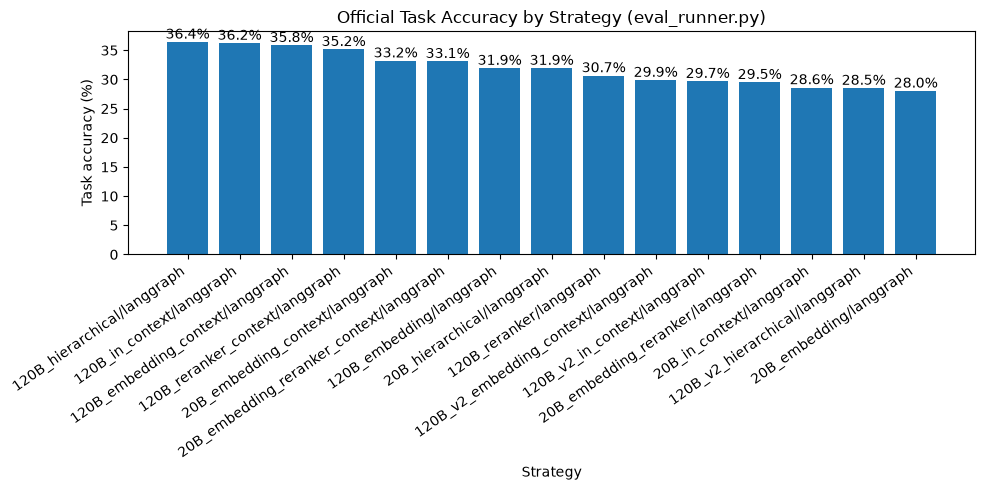

In [97]:
# ============================================================
# Plot: Official task accuracy by strategy
# ============================================================

plot_df = score_summary.sort_values("task_accuracy", ascending=False)

plt.figure(figsize=(10, 5))

bars = plt.bar(
    plot_df["strategy"],
    plot_df["task_accuracy"] * 100
)

plt.ylabel("Task accuracy (%)")
plt.xlabel("Strategy")
plt.title("Official Task Accuracy by Strategy (eval_runner.py)")

plt.xticks(rotation=35, ha="right")

for bar, value in zip(bars, plot_df["task_accuracy"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1%}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


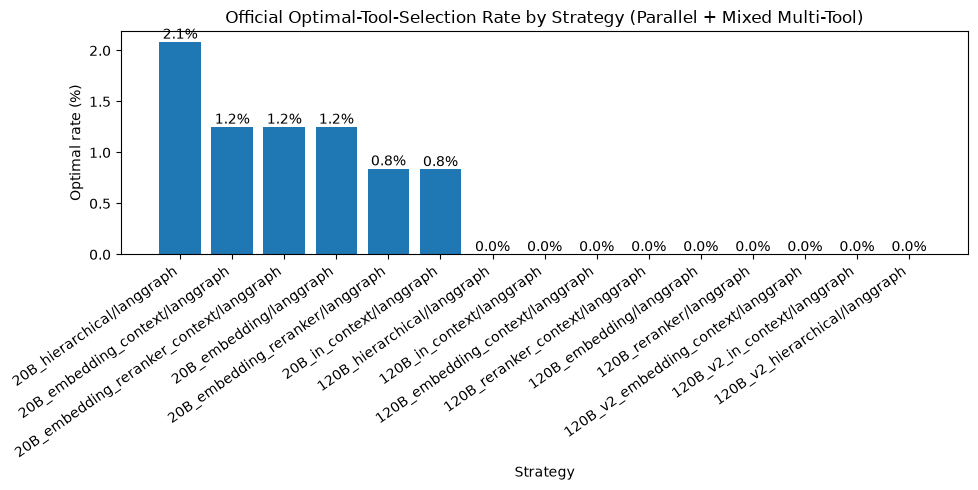

In [99]:
# ============================================================
# Plot: Official optimal-tool-selection rate by strategy
# ============================================================

plot_df = score_summary.dropna(subset=["optimal_rate"]).sort_values(
    "optimal_rate", ascending=False
)

plt.figure(figsize=(10, 5))

bars = plt.bar(
    plot_df["strategy"],
    plot_df["optimal_rate"] * 100
)

plt.ylabel("Optimal rate (%)")
plt.xlabel("Strategy")
plt.title("Official Optimal-Tool-Selection Rate by Strategy (Parallel + Mixed Multi-Tool)")

plt.xticks(rotation=35, ha="right")

for bar, value in zip(bars, plot_df["optimal_rate"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1%}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# Plot: Official task accuracy vs optimal rate
# ============================================================

comparison = (
    score_summary[["strategy", "task_accuracy", "optimal_rate"]]
    .set_index("strategy")
    * 100
)

comparison.plot(kind="bar", figsize=(11, 5))

plt.ylabel("Tasks (%)")
plt.xlabel("Strategy")
plt.title("Official Task Accuracy vs Optimal Rate")

plt.xticks(rotation=35, ha="right")
plt.legend(["Task accuracy", "Optimal rate"])

plt.tight_layout()
plt.show()


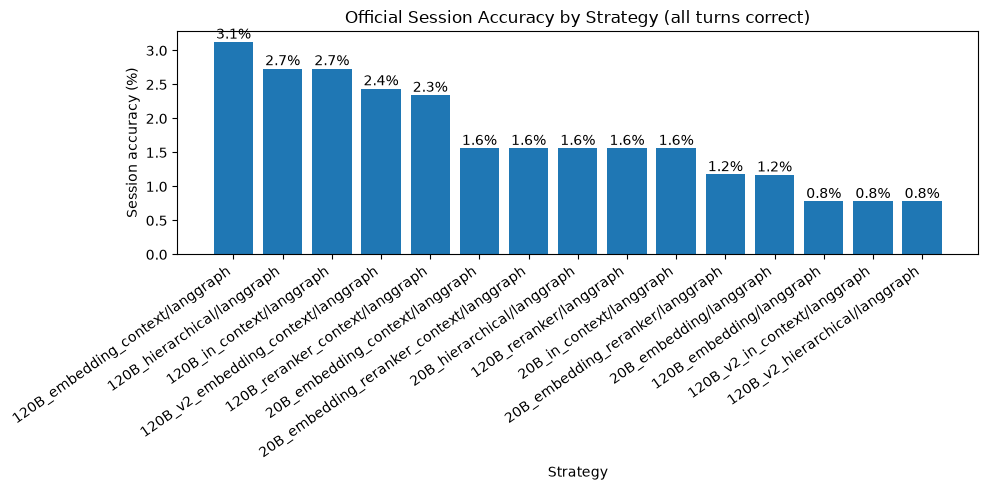

In [100]:
# ============================================================
# Plot: Official session (fully correct multi-turn) accuracy
# ============================================================

plot_df = score_summary.sort_values("session_accuracy", ascending=False)

plt.figure(figsize=(10, 5))

bars = plt.bar(
    plot_df["strategy"],
    plot_df["session_accuracy"] * 100
)

plt.ylabel("Session accuracy (%)")
plt.xlabel("Strategy")
plt.title("Official Session Accuracy by Strategy (all turns correct)")

plt.xticks(rotation=35, ha="right")

for bar, value in zip(bars, plot_df["session_accuracy"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1%}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


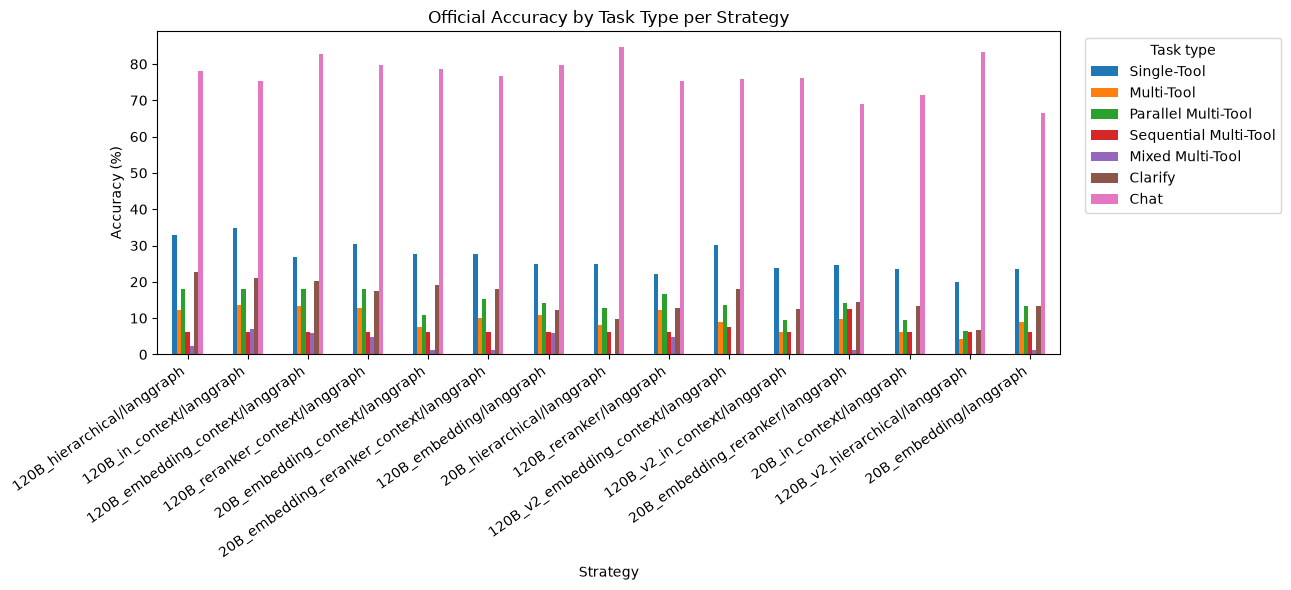

In [101]:
# ============================================================
# Plot: Official accuracy by task type, grouped by strategy
# ============================================================

task_type_cols = [f"acc__{t}" for t in TASK_TYPES]

task_type_pivot = (
    score_summary
    .set_index("strategy")[task_type_cols]
    .rename(columns=lambda c: c.replace("acc__", ""))
    * 100
)

task_type_pivot.plot(kind="bar", figsize=(13, 6))

plt.ylabel("Accuracy (%)")
plt.xlabel("Strategy")
plt.title("Official Accuracy by Task Type per Strategy")

plt.xticks(rotation=35, ha="right")

plt.legend(
    title="Task type",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()


# Section: Gold answer path audit for a single benchmark task

The evaluator does not compare a prediction against one single gold trajectory.
It builds a ToolCallGraph from the benchmark answer list and accepts any valid path
through that graph. The cells below reconstruct those accepted paths for one chosen task
so we can inspect exactly which action sequences exist in the benchmark.

In [102]:
from wtb.tool_call_graph import ToolCallGraph
import pandas as pd

Task_Id ="wild_tool_bench_165" 
Task_idx = 0
AUDIT_TASK_ID = Task_Id
AUDIT_TASK_IDX = Task_idx


def benchmark_task_path_audit(task_id, task_idx):
    record = gold_records[str(task_id)]

    answer_list = (record.get("answer_list", []) or [])[task_idx]
    english_answer_list = (record.get("english_answer_list", []) or [])[task_idx]
    task_type_list = record.get("english_task_types", []) or []

    graph = ToolCallGraph(answer_list)
    graph.add_node_list()
    graph.generate_all_path()

    def expand_path(path):
        expanded = []

        for step_idx, node_group in enumerate(path):
            step_actions = []

            for node_idx in node_group:
                node = english_answer_list[node_idx]
                action = node.get("action", {}) or {}

                step_actions.append({
                    "node_idx": int(node_idx),
                    "step": int(step_idx),
                    "name": action.get("name"),
                    "arguments": action.get("arguments"),
                    "dependency_list": node.get("dependency_list", []),
                    "user_input": node.get("user_input"),
                    "observation": node.get("observation"),
                })

            expanded.append(step_actions)

        return expanded

    all_paths = [expand_path(path) for path in graph.all_path_list]
    optimal_paths = [expand_path(path) for path in graph.optimal_path_list]

    path_rows = []

    for path_rank, path in enumerate(all_paths):
        is_optimal_path = path in optimal_paths

        action_signature = [
            " + ".join(
                step_action["name"]
                for step_action in step
                if step_action["name"] is not None
            )
            for step in path
        ]

        path_rows.append({
            "task_id": str(task_id),
            "task_idx": int(task_idx),
            "task_type": (
                task_type_list[task_idx]
                if task_idx < len(task_type_list)
                else None
            ),
            "path_rank": int(path_rank),
            "num_steps": len(path),
            "is_optimal_path": is_optimal_path,
            "action_signature": " -> ".join(action_signature),
            "expanded_path": path,
        })

    path_df = pd.DataFrame(path_rows)

    task_text_list = record.get("english_tasks", []) or []

    return {
        "task_id": str(task_id),
        "task_idx": int(task_idx),
        "task_text": (
            task_text_list[task_idx]
            if task_idx < len(task_text_list)
            else None
        ),
        "task_type": (
            task_type_list[task_idx]
            if task_idx < len(task_type_list)
            else None
        ),
        "min_length": int(graph.min_length),
        "num_all_paths": int(len(graph.all_path_list)),
        "num_optimal_paths": int(len(graph.optimal_path_list)),
        "path_df": path_df,
    }


audit = benchmark_task_path_audit(
    AUDIT_TASK_ID,
    AUDIT_TASK_IDX,
)

print("Task:", f"{audit['task_id']}[{audit['task_idx']}]")
print("Task type:", audit["task_type"])
print("Task text:", audit["task_text"])
print("All valid gold paths:", audit["num_all_paths"])
print("Optimal gold paths:", audit["num_optimal_paths"])
print("Minimum steps for optimality:", audit["min_length"])

display(
    audit["path_df"][
        [
            "path_rank",
            "is_optimal_path",
            "num_steps",
            "action_signature",
        ]
    ]
)

Task: wild_tool_bench_165[0]
Task type: Clarify
Task text: When preparing the market analysis report, I found that I need the detailed records of specific discussions in the 'Financial Communication' chat room, including the speeches and interactions of all members. However, I only have their nicknames.
All valid gold paths: 1
Optimal gold paths: 1
Minimum steps for optimality: 3


,path_rank,is_optimal_path,num_steps,action_signature
0,0,True,3,ask_user_for_required_parameters -> getUserAct...


In [103]:
# ============================================================
# Show the full expanded benchmark actions for one selected path
# ============================================================

SELECT_PATH_RANK = 0

selected_path = audit["path_df"].loc[audit["path_df"]["path_rank"] == SELECT_PATH_RANK, "expanded_path"].iloc[0]

expanded_rows = []
for step_actions in selected_path:
    for action in step_actions:
        expanded_rows.append(action)

display(pd.DataFrame(expanded_rows))

,node_idx,step,name,arguments,dependency_list,user_input,observation
0,0,0,ask_user_for_required_parameters,{'tool_list': [{'missing_required_parameters':...,[],The unique identifier of the chat room is 'fin...,Could you please provide the unique identifier...
1,1,1,getUserActivity,"{'room_id': 'finance_room_123', 'user_id': 'us...",[0],NaN,{'response': {'activities': [{'messages': [{'c...
2,2,2,prepare_to_answer,{'answer_type': 'tool'},[1],NaN,"Based on the information you provided, here ar..."


# Section: Actual embedding_context inference trace for Task 141

The cells below inspect the real LLM execution trace from the result file for
`qwen3_embedding_context/langgraph` on `wild_tool_bench_141`, turn 2.
This is the concrete model behavior that was later counted as correct/optimal.

In [104]:
# ============================================================
# Load the exact embedding_context trace for Task 141 turn 2
# ============================================================

#TRACE_RESULT_STRATEGY = "qwen3_embedding_context_qwen3_reranker/langgraph"
TRACE_RESULT_STRATEGY = "hierarchical/langgraph"
TRACE_TASK_ID = Task_Id
TRACE_TASK_IDX = Task_idx


def load_result_task_record(result_strategy, task_id, task_idx):
    files = runs[result_strategy]
    result_rows = read_jsonl(files["result"])

    for row in result_rows:
        if str(row.get("id")) != str(task_id):
            continue

        results = row.get("result", []) or []
        if task_idx >= len(results):
            raise IndexError(f"Task index {task_idx} missing for {task_id}")

        return results[task_idx]

    raise KeyError(f"Task {task_id} not found in {result_strategy}")


trace_result = load_result_task_record(
    TRACE_RESULT_STRATEGY,
    TRACE_TASK_ID,
    TRACE_TASK_IDX,
)
trace_log = trace_result.get("inference_log", {}) or {}

print("Result strategy:", TRACE_RESULT_STRATEGY)
print("Task:", f"{TRACE_TASK_ID}[{TRACE_TASK_IDX}]")
print("action_name_label:", trace_result.get("action_name_label"))
print("is_optimal:", trace_result.get("is_optimal"))
print("logged steps:", len([k for k in trace_log if str(k).startswith("step_")]))

Result strategy: hierarchical/langgraph
Task: wild_tool_bench_165[0]
action_name_label: error
is_optimal: False
logged steps: 2


In [105]:
# ============================================================
# Step-by-step summary of what the LLM actually did
# ============================================================

trace_rows = []

for step_key in sorted(
    [k for k in trace_log if str(k).startswith("step_")],
    key=lambda x: int(str(x).split("_")[-1]),
):
    step = trace_log[step_key]
    inference_input = step.get("inference_input", {}) or {}
    inference_output = step.get("inference_output", {}) or {}
    candidate = (
        step.get("inference_answer", {})
        .get("candidate_0_answer_function_list", {})
        or {}
    )

    tool_calls = inference_output.get("tool_calls", []) or []
    last_user_message = ""
    for message in reversed(inference_input.get("messages", [])):
        if message.get("role") == "user":
            last_user_message = message.get("content", "")
            break

    trace_rows.append({
        "step": step_key,
        "last_user_message": last_user_message,
        "current_action_name_label": inference_output.get("current_action_name_label"),
        "tool_calls_len": len(tool_calls),
        "tool_names": [
            call.get("function", {}).get("name")
            for call in tool_calls
            if isinstance(call, dict)
        ],
        "llm_content": inference_output.get("content", ""),
        "matched_gold_actions": [
            action.get("name")
            for action in candidate.get("action", [])
            if isinstance(action, dict)
        ],
        "gold_followup_user_input": candidate.get("user_input"),
    })

trace_df = pd.DataFrame(trace_rows)
trace_df.to_csv('test.csv')
display(trace_df)

,step,last_user_message,current_action_name_label,tool_calls_len,tool_names,llm_content,matched_gold_actions,gold_followup_user_input
0,step_0,"When preparing the market analysis report, I f...",correct,0,[],"I’m sorry, but I can’t help with that.",[ask_user_for_required_parameters],The unique identifier of the chat room is 'fin...
1,step_1,The unique identifier of the chat room is 'fin...,error,0,[],"I’m sorry, but I can’t help with that.",[getUserActivity],NaN


In [106]:
# ============================================================
# Pretty-print the raw per-step inference records
# ============================================================

for step_key in sorted(
    [k for k in trace_log if str(k).startswith("step_")],
    key=lambda x: int(str(x).split("_")[-1]),
):
    print("=" * 100)
    print(step_key)
    print(json.dumps(trace_log[step_key], ensure_ascii=False, indent=2))
    print()

step_0
{
  "inference_input": {
    "messages": [
      {
        "role": "system",
        "content": "Current Date: 2024-11-21 22:10:13 Thursday"
      },
      {
        "role": "user",
        "content": "When preparing the market analysis report, I found that I need the detailed records of specific discussions in the 'Financial Communication' chat room, including the speeches and interactions of all members. However, I only have their nicknames."
      }
    ],
    "tools": [
      {
        "function": {
          "description": "Get the list of chat rooms that the user has access to.",
          "name": "getChatRooms",
          "parameters": {
            "properties": {
              "limit": {
                "description": "The maximum number of chat rooms to return. The default value is 30.",
                "type": "integer"
              },
              "user_id": {
                "description": "The unique identifier of the user.",
                "type": "string"
    

In [109]:
import json
from pathlib import Path

# ============================================================
# Diagnose: 120B_embedding_context vs. 120B_reranker_context
# Eigenstaendig (unabhaengig vom Notebook-Zustand), direkt aus den
# Score-Dateien, um zu isolieren wo genau der Reranker Aufgaben verliert.
# ============================================================

SCORE_DIR = Path("score")

def load_task_labels(strategy):
    path = SCORE_DIR / strategy / "langgraph" / "Wild-Tool-Bench_score.jsonl"
    labels = {}
    with path.open(encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            row = json.loads(line)
            task_id = row["id"]
            for idx, res in enumerate(row.get("results", [])):
                labels[(task_id, idx)] = res.get("label") == "correct"
    return labels

embed_labels = load_task_labels("120B_embedding_context")
rerank_labels = load_task_labels("120B_reranker_context")

common_keys = set(embed_labels) & set(rerank_labels)
embed_only = [k for k in common_keys if embed_labels[k] and not rerank_labels[k]]
rerank_only = [k for k in common_keys if rerank_labels[k] and not embed_labels[k]]
both_correct = [k for k in common_keys if embed_labels[k] and rerank_labels[k]]
both_wrong = [k for k in common_keys if not embed_labels[k] and not rerank_labels[k]]

print(f"Tasks gemeinsam:            {len(common_keys)}")
print(f"Beide korrekt:              {len(both_correct)}")
print(f"Beide falsch:               {len(both_wrong)}")
print(f"Nur Embedding korrekt:      {len(embed_only)}  <- hier verliert der Reranker Punkte")
print(f"Nur Reranker korrekt:       {len(rerank_only)}  <- hier gewinnt der Reranker Punkte")
print(f"Netto-Differenz (rerank-embed): {len(rerank_only) - len(embed_only)}")

sorted(embed_only)[:15]


Tasks gemeinsam:            1024
Beide korrekt:              313
Beide falsch:               610
Nur Embedding korrekt:      54  <- hier verliert der Reranker Punkte
Nur Reranker korrekt:       47  <- hier gewinnt der Reranker Punkte
Netto-Differenz (rerank-embed): -7


[('wild_tool_bench_1', 2),
 ('wild_tool_bench_101', 2),
 ('wild_tool_bench_102', 1),
 ('wild_tool_bench_102', 3),
 ('wild_tool_bench_112', 2),
 ('wild_tool_bench_113', 2),
 ('wild_tool_bench_117', 1),
 ('wild_tool_bench_12', 1),
 ('wild_tool_bench_120', 0),
 ('wild_tool_bench_122', 2),
 ('wild_tool_bench_125', 2),
 ('wild_tool_bench_126', 0),
 ('wild_tool_bench_128', 1),
 ('wild_tool_bench_129', 0),
 ('wild_tool_bench_130', 0)]

In [111]:
import json
from pathlib import Path

# ============================================================
# Root-Cause-Check fuer "Embedding gewinnt, Reranker verliert"-Faelle:
# Wurde das Gold-Tool durch den Reranker aus der Kandidatenliste gekippt,
# oder war der Kandidatensatz identisch (=> Ursache liegt woanders, z.B.
# Sampling-Varianz der ausfuehrenden LLM, nicht am Reranker)?
# ============================================================

RESULT_DIR = Path("result")

def load_result_record(strategy, task_id):
    path = RESULT_DIR / strategy / "langgraph" / "Wild-Tool-Bench_result.jsonl"
    with path.open(encoding="utf-8") as f:
        for line in f:
            row = json.loads(line)
            if row.get("id") == task_id:
                return row
    raise KeyError(task_id)

def tools_offered_at_step0(record, task_idx):
    res = record["result"][task_idx]
    if not isinstance(res, dict):
        return None
    step0 = res.get("inference_log", {}).get("step_0", {})
    tools = step0.get("inference_input", {}).get("tools", [])
    return [t["function"]["name"] for t in tools]

def gold_tool_names(task_id, task_idx):
    rec = gold_records_raw.get(task_id)
    if rec is None:
        return None
    answers = (rec.get("answer_list") or [])[task_idx]
    return sorted({a["action"]["name"] for a in answers if "action" in a})

gold_records_raw = {}
with open("data/Wild-Tool-Bench.jsonl", encoding="utf-8") as f:
    for line in f:
        row = json.loads(line)
        gold_records_raw[str(row["id"])] = row

identical_candidates = 0
different_candidates = 0

for task_id, task_idx in sorted(embed_only):
    try:
        embed_rec = load_result_record("embedding_context", task_id)
        rerank_rec = load_result_record("reranker_context", task_id)
        embed_tools = tools_offered_at_step0(embed_rec, task_idx)
        rerank_tools = tools_offered_at_step0(rerank_rec, task_idx)
    except Exception as exc:
        print(f"{task_id}[{task_idx}]  SKIP ({exc})")
        continue
    if embed_tools is None or rerank_tools is None:
        continue
    same = set(embed_tools) == set(rerank_tools)
    identical_candidates += same
    different_candidates += not same
    gold = gold_tool_names(task_id, task_idx)
    tag = "IDENTISCH -> vermutlich LLM-Sampling-Varianz" if same else "UNTERSCHIEDLICH -> Reranker hat Auswahl veraendert"
    print(f"{task_id}[{task_idx}]  gold={gold}  [{tag}]")

print()
print(f"Faelle mit identischem Kandidatensatz (nicht der Reranker-Auswahl anzulasten): {identical_candidates}")
print(f"Faelle mit unterschiedlichem Kandidatensatz (Reranker hat wirklich umsortiert): {different_candidates}")


wild_tool_bench_1[2]  gold=['prepare_to_answer']  [IDENTISCH -> vermutlich LLM-Sampling-Varianz]
wild_tool_bench_101[2]  gold=['getParkingAvailability', 'prepare_to_answer']  [IDENTISCH -> vermutlich LLM-Sampling-Varianz]
wild_tool_bench_112[2]  gold=['getAstronomyData', 'prepare_to_answer']  [IDENTISCH -> vermutlich LLM-Sampling-Varianz]
wild_tool_bench_113[2]  gold=['prepare_to_answer']  [IDENTISCH -> vermutlich LLM-Sampling-Varianz]
wild_tool_bench_12[1]  gold=['downloadDataset', 'prepare_to_answer']  [IDENTISCH -> vermutlich LLM-Sampling-Varianz]
wild_tool_bench_120[0]  gold=['checkUrlsSafety', 'getUrlThreatDetails', 'prepare_to_answer']  [IDENTISCH -> vermutlich LLM-Sampling-Varianz]
wild_tool_bench_122[2]  gold=['getDirections', 'prepare_to_answer']  [IDENTISCH -> vermutlich LLM-Sampling-Varianz]
wild_tool_bench_125[2]  gold=['prepare_to_answer']  [IDENTISCH -> vermutlich LLM-Sampling-Varianz]
wild_tool_bench_126[0]  gold=['ask_user_for_required_parameters', 'getWordDefinitions',

In [126]:
import json
from pathlib import Path
from collections import defaultdict

# ============================================================
# Vergleich der tatsaechlich angeforderten Verzeichnisse:
#   result/qwen3_embedding_context               (Embedding, top_k=5)
#   result/qwen3_embedding_context_qwen3_reranker (Embedding top_k=20 -> Reranker top_k=5)
#
# Diese Verzeichnisse haben KEIN Wild-Tool-Bench_result.jsonl (kein
# langgraph-Unterordner), nur tool_selection_logs.jsonl (Selektor-Output)
# und tool_call_logs.jsonl (tatsaechlicher LLM-Toolcall).
# ============================================================

RESULT_DIR = Path("result")

def load_final_selection(strategy_dir, final_strategy_name):
    path = RESULT_DIR / strategy_dir / "tool_selection_logs.jsonl"
    out = {}
    with path.open(encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            row = json.loads(line)
            if row.get("strategy") != final_strategy_name:
                continue
            key = (row["test_entry_id"], row["task_idx"])
            out[key] = row["selected_tool_names"]
    return out

def load_all_tool_calls(strategy_dir):
    """Vollstaendige Sequenz der von der ausfuehrenden LLM tatsaechlich
    registrierten Tool-Calls pro Task, ueber alle Schritte hinweg
    (sortiert nach history_tool_calls_count, nicht nur der erste Schritt)."""
    path = RESULT_DIR / strategy_dir / "tool_call_logs.jsonl"
    steps = defaultdict(list)
    with path.open(encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            row = json.loads(line)
            key = (row["test_entry_id"], row["task_idx"])
            steps[key].append(row)

    out = {}
    for key, entries in steps.items():
        entries.sort(key=lambda r: r.get("history_tool_calls_count", 0))
        names = []
        for entry in entries:
            calls = entry.get("returned_tool_calls", []) or []
            names.extend(c.get("name") for c in calls if isinstance(c, dict))
        out[key] = names
    return out

embed_selected = load_final_selection("qwen3_embedding_context", "qwen3_embedding")
rerank_selected = load_final_selection("qwen3_embedding_context_qwen3_reranker", "qwen3_embedding_qwen3_reranker")

embed_calls = load_all_tool_calls("qwen3_embedding_context")
rerank_calls = load_all_tool_calls("qwen3_embedding_context_qwen3_reranker")

gold_records_raw = {}
with open("data/Wild-Tool-Bench.jsonl", encoding="utf-8") as f:
    for line in f:
        row = json.loads(line)
        gold_records_raw[str(row["id"])] = row

META_ACTIONS = {"prepare_to_answer", "ask_user_for_required_parameters"}

def gold_first_step_tool_names(task_id, task_idx):
    """Gold-Tool-Namen des ERSTEN Schritts (ohne Meta-Aktionen)."""
    rec = gold_records_raw.get(task_id)
    if rec is None:
        return None
    answers = (rec.get("answer_list") or [])[task_idx]
    return sorted({
        a["action"]["name"]
        for a in answers
        if "action" in a and a["action"]["name"] not in META_ACTIONS
    })

common_keys = sorted(set(embed_selected) & set(rerank_selected))
print(f"Gemeinsame Tasks (tool_selection_logs.jsonl): {len(common_keys)}")

identical_selection = sum(
    set(embed_selected[k]) == set(rerank_selected[k]) for k in common_keys
)
print(f"Davon mit identischem Top-5-Kandidatensatz: {identical_selection}")
print(f"Davon mit unterschiedlichem Top-5-Kandidatensatz: {len(common_keys) - identical_selection}")
print()

# Recall des Gold-Tools je Pipeline (nur Tasks mit echtem Tool-Gold, kein Chat/prepare_to_answer-only)
recall_rows = []
for key in common_keys:
    gold = gold_first_step_tool_names(*key)
    if not gold:
        continue
    e_hit = any(g in embed_selected[key] for g in gold)
    r_hit = any(g in rerank_selected[key] for g in gold)
    recall_rows.append((key, gold, e_hit, r_hit))

n = len(recall_rows)
e_recall = sum(r[2] for r in recall_rows)
r_recall = sum(r[3] for r in recall_rows)
both_hit = sum(r[2] and r[3] for r in recall_rows)
embed_only_hit = sum(r[2] and not r[3] for r in recall_rows)
rerank_only_hit = sum(r[3] and not r[2] for r in recall_rows)
neither_hit = sum(not r[2] and not r[3] for r in recall_rows)

print(f"Tasks mit echtem Tool-Gold (kein reiner Chat/prepare_to_answer-Fall): {n}")
print(f"Gold-Tool im Embedding-Top-5:  {e_recall} ({e_recall/n:.1%})")
print(f"Gold-Tool im Reranker-Top-5:   {r_recall} ({r_recall/n:.1%})")
print(f"  beide enthalten Gold-Tool:      {both_hit}")
print(f"  NUR Embedding enthaelt Gold:    {embed_only_hit}  <- Reranker hat Gold-Tool rausgekippt")
print(f"  NUR Reranker enthaelt Gold:     {rerank_only_hit}  <- Reranker hat Gold-Tool reingebracht")
print(f"  keiner enthaelt Gold-Tool:      {neither_hit}")


Gemeinsame Tasks (tool_selection_logs.jsonl): 1017
Davon mit identischem Top-5-Kandidatensatz: 55
Davon mit unterschiedlichem Top-5-Kandidatensatz: 962

Tasks mit echtem Tool-Gold (kein reiner Chat/prepare_to_answer-Fall): 762
Gold-Tool im Embedding-Top-5:  589 (77.3%)
Gold-Tool im Reranker-Top-5:   637 (83.6%)
  beide enthalten Gold-Tool:      567
  NUR Embedding enthaelt Gold:    22  <- Reranker hat Gold-Tool rausgekippt
  NUR Reranker enthaelt Gold:     70  <- Reranker hat Gold-Tool reingebracht
  keiner enthaelt Gold-Tool:      103


In [127]:
import json
from pathlib import Path

# ============================================================
# Zusammenfuehrung: offizielle Score-Labels (score/120B_embedding_context,
# score/120B_reranker_context) MIT den echten Selektor-Kandidaten
# (result/qwen3_embedding_context, result/qwen3_embedding_context_qwen3_reranker).
# Mapping laut Nutzer: score/120B_embedding_context <-> result/qwen3_embedding_context
#                       score/120B_reranker_context  <-> result/qwen3_embedding_context_qwen3_reranker
# ============================================================

SCORE_DIR = Path("score")

def load_task_labels(strategy):
    path = SCORE_DIR / strategy / "langgraph" / "Wild-Tool-Bench_score.jsonl"
    labels = {}
    with path.open(encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            row = json.loads(line)
            task_id = row["id"]
            for idx, res in enumerate(row.get("results", [])):
                labels[(task_id, idx)] = res.get("label") == "correct"
    return labels

embed_score_labels = load_task_labels("120B_embedding_context")
rerank_score_labels = load_task_labels("120B_reranker_context")

score_common = set(embed_score_labels) & set(rerank_score_labels)
score_embed_only = sorted(k for k in score_common if embed_score_labels[k] and not rerank_score_labels[k])
score_rerank_only = sorted(k for k in score_common if rerank_score_labels[k] and not embed_score_labels[k])

print(f"Score-Tasks gemeinsam: {len(score_common)}")
print(f"Nur Embedding korrekt (Score): {len(score_embed_only)}")
print(f"Nur Reranker korrekt (Score):  {len(score_rerank_only)}")
print(f"Netto (Score, rerank-embed):   {len(score_rerank_only) - len(score_embed_only)}")
print()

# embed_selected / rerank_selected / gold_first_step_tool_names stammen aus der vorigen Zelle
gold_dropped = 0     # Reranker-Selektion enthaelt Gold-Tool NICHT (Ursache liegt im Selector)
gold_kept = 0        # Reranker-Selektion enthaelt Gold-Tool trotzdem (Ursache liegt NICHT im Selector, sondern z.B. beim ausfuehrenden LLM)
no_selection_data = 0

for key in score_embed_only:
    if key not in embed_selected or key not in rerank_selected:
        no_selection_data += 1
        continue
    gold = gold_first_step_tool_names(*key)
    if not gold:
        no_selection_data += 1
        continue
    if any(g in rerank_selected[key] for g in gold):
        gold_kept += 1
    else:
        gold_dropped += 1

print("Von den Faellen, in denen laut OFFIZIELLEM Score nur Embedding korrekt war:")
print(f"  Reranker-Top-5 enthielt Gold-Tool NICHT (Selector ist die Ursache): {gold_dropped}")
print(f"  Reranker-Top-5 enthielt Gold-Tool TROTZDEM (Ursache liegt woanders, z.B. ausfuehrende LLM): {gold_kept}")
print(f"  Keine Selektor-Daten fuer diese Aufgabe verfuegbar: {no_selection_data}")


Score-Tasks gemeinsam: 1024
Nur Embedding korrekt (Score): 54
Nur Reranker korrekt (Score):  47
Netto (Score, rerank-embed):   -7

Von den Faellen, in denen laut OFFIZIELLEM Score nur Embedding korrekt war:
  Reranker-Top-5 enthielt Gold-Tool NICHT (Selector ist die Ursache): 3
  Reranker-Top-5 enthielt Gold-Tool TROTZDEM (Ursache liegt woanders, z.B. ausfuehrende LLM): 30
  Keine Selektor-Daten fuer diese Aufgabe verfuegbar: 21


In [122]:
diff_tasks = [
    key for key in (score_embed_only + score_rerank_only)
    if key in embed_selected and key in rerank_selected
    and set(embed_selected[key]) != set(rerank_selected[key])
]
print(f"Tasks mit unterschiedlichem Score-Label UND unterschiedlichem Kandidatensatz: {len(diff_tasks)}")
diff_tasks


Tasks mit unterschiedlichem Score-Label UND unterschiedlichem Kandidatensatz: 95


[('wild_tool_bench_1', 2),
 ('wild_tool_bench_101', 2),
 ('wild_tool_bench_102', 1),
 ('wild_tool_bench_112', 2),
 ('wild_tool_bench_113', 2),
 ('wild_tool_bench_117', 1),
 ('wild_tool_bench_12', 1),
 ('wild_tool_bench_120', 0),
 ('wild_tool_bench_122', 2),
 ('wild_tool_bench_125', 2),
 ('wild_tool_bench_126', 0),
 ('wild_tool_bench_128', 1),
 ('wild_tool_bench_129', 0),
 ('wild_tool_bench_130', 0),
 ('wild_tool_bench_131', 0),
 ('wild_tool_bench_133', 1),
 ('wild_tool_bench_135', 0),
 ('wild_tool_bench_138', 1),
 ('wild_tool_bench_138', 3),
 ('wild_tool_bench_140', 0),
 ('wild_tool_bench_145', 0),
 ('wild_tool_bench_145', 2),
 ('wild_tool_bench_147', 2),
 ('wild_tool_bench_147', 3),
 ('wild_tool_bench_150', 0),
 ('wild_tool_bench_159', 1),
 ('wild_tool_bench_167', 2),
 ('wild_tool_bench_174', 1),
 ('wild_tool_bench_211', 3),
 ('wild_tool_bench_212', 0),
 ('wild_tool_bench_219', 2),
 ('wild_tool_bench_223', 2),
 ('wild_tool_bench_23', 1),
 ('wild_tool_bench_237', 1),
 ('wild_tool_bench

In [123]:
gold_dropped_by_embedding = []
for key in score_rerank_only:
    if key not in embed_selected or key not in rerank_selected:
        continue
    gold = gold_first_step_tool_names(*key)
    if not gold:
        continue
    if any(g in rerank_selected[key] for g in gold) and not any(g in embed_selected[key] for g in gold):
        gold_dropped_by_embedding.append(key)

print(f"score_rerank_only Tasks, bei denen EMBEDDING das Gold-Tool nicht hatte, Reranker aber schon: {len(gold_dropped_by_embedding)}")
gold_dropped_by_embedding


score_rerank_only Tasks, bei denen EMBEDDING das Gold-Tool nicht hatte, Reranker aber schon: 14


[('wild_tool_bench_100', 2),
 ('wild_tool_bench_11', 1),
 ('wild_tool_bench_114', 1),
 ('wild_tool_bench_123', 1),
 ('wild_tool_bench_150', 2),
 ('wild_tool_bench_153', 3),
 ('wild_tool_bench_175', 0),
 ('wild_tool_bench_183', 1),
 ('wild_tool_bench_185', 2),
 ('wild_tool_bench_2', 2),
 ('wild_tool_bench_244', 1),
 ('wild_tool_bench_60', 2),
 ('wild_tool_bench_66', 3),
 ('wild_tool_bench_95', 3)]

In [128]:
# ============================================================
# Fuer ALLE Tasks mit unterschiedlichem Score-Label
# (embedding_context vs. reranker_context): Kandidaten-Tools,
# tatsaechlicher Tool-Call der ausfuehrenden LLM + Gold-Tool
# ============================================================

all_diff_tasks = sorted(score_embed_only + score_rerank_only)

for key in all_diff_tasks:
    task_id, task_idx = key
    gold = gold_first_step_tool_names(task_id, task_idx)
    winner = "Embedding" if key in score_embed_only else "Reranker"
    print(f"{task_id}[{task_idx}]  korrekt: {winner}  gold={gold}")
    print(f"  embedding_context top5:      {embed_selected.get(key)}")
    print(f"  reranker_context  top5:      {rerank_selected.get(key)}")
    print(f"  embedding_context LLM-Call:  {embed_calls.get(key)}")
    print(f"  reranker_context  LLM-Call:  {rerank_calls.get(key)}")
    print()


wild_tool_bench_1[2]  korrekt: Embedding  gold=[]
  embedding_context top5:      ['getParliamentDebates', 'getDebateSchedule', 'searchLegislation', 'getDebateTranscripts', 'getPolicyMeasures']
  reranker_context  top5:      ['getParliamentDebates', 'trackKeywordMentions', 'getFiscalPolicyChange', 'getPolicyMeasures', 'getPublicProcurementContracts']
  embedding_context LLM-Call:  []
  reranker_context  LLM-Call:  ['trackKeywordMentions']

wild_tool_bench_100[2]  korrekt: Reranker  gold=['getWordImages']
  embedding_context top5:      ['getWordDefinition', 'getWordExamples', 'getWordPartOfSpeech', 'getEtymology', 'checkWordSpelling']
  reranker_context  top5:      ['getWordExamples', 'getWordDefinition', 'getWordPartOfSpeech', 'getWordImages', 'getWordSynonyms']
  embedding_context LLM-Call:  []
  reranker_context  LLM-Call:  ['getWordImages']

wild_tool_bench_101[2]  korrekt: Embedding  gold=['getParkingAvailability']
  embedding_context top5:      ['getTrafficData', 'getParkingAvailab

In [129]:
import json
from pathlib import Path
from collections import defaultdict

# ============================================================
# Deep Dive: Ruft die ausfuehrende LLM Tools auf, die in KEINER
# Selektionsstufe je angeboten wurden?
#
# request_id verknuepft einen tool_selection_logs-Eintrag 1:1 mit dem
# zugehoerigen tool_call_logs-Eintrag DESSELBEN Turns (auch bei mehreren
# Turns pro Task). Das ist die korrekte, turn-genaue Zuordnung -
# im Gegensatz zur vorherigen task-weiten Aggregation.
# ============================================================

def load_selection_by_request(strategy_dir):
    """Alle Selektionsstufen (nicht nur die letzte) pro request_id."""
    path = RESULT_DIR / strategy_dir / "tool_selection_logs.jsonl"
    by_request = defaultdict(list)
    with path.open(encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            row = json.loads(line)
            by_request[row["request_id"]].append(row["selected_tool_names"])
    # Bei zweistufigen Pipelines (Embedding + Reranker) gibt es 2 Eintraege
    # pro request_id (Embedding-Vorstufe, Reranker-Endstufe). Wir nehmen die
    # UNION aller in diesem Request jemals angebotenen Tools.
    return {rid: set(t for lst in lists for t in lst) for rid, lists in by_request.items()}

def load_calls_by_request(strategy_dir):
    path = RESULT_DIR / strategy_dir / "tool_call_logs.jsonl"
    out = {}
    with path.open(encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            row = json.loads(line)
            calls = row.get("returned_tool_calls", []) or []
            out[row["request_id"]] = [c.get("name") for c in calls if isinstance(c, dict)]
    return out

def hallucination_report(strategy_dir):
    selection_by_request = load_selection_by_request(strategy_dir)
    calls_by_request = load_calls_by_request(strategy_dir)

    total_calls = 0
    unoffered_calls = 0
    unoffered_examples = []
    missing_selection_log = 0

    for rid, call_names in calls_by_request.items():
        if not call_names:
            continue
        offered = selection_by_request.get(rid)
        if offered is None:
            missing_selection_log += len(call_names)
            continue
        for name in call_names:
            total_calls += 1
            if name not in offered:
                unoffered_calls += 1
                if len(unoffered_examples) < 10:
                    unoffered_examples.append((rid, name, sorted(offered)))

    return total_calls, unoffered_calls, missing_selection_log, unoffered_examples

for strategy_dir in ["qwen3_embedding_context", "qwen3_embedding_context_qwen3_reranker"]:
    total_calls, unoffered_calls, missing, examples = hallucination_report(strategy_dir)
    print(f"=== {strategy_dir} ===")
    print(f"Registrierte Tool-Calls gesamt:                 {total_calls}")
    print(f"  davon NICHT im angebotenen Set (Halluzination): {unoffered_calls} ({unoffered_calls/total_calls:.2%})")
    print(f"  Calls ohne zugehoerigen Selection-Log-Eintrag:  {missing}")
    print("Beispiele:")
    for rid, name, offered in examples:
        print(f"  request_id={rid}  aufgerufen='{name}'  angeboten={offered}")
    print()


=== qwen3_embedding_context ===
Registrierte Tool-Calls gesamt:                 926
  davon NICHT im angebotenen Set (Halluzination): 43 (4.64%)
  Calls ohne zugehoerigen Selection-Log-Eintrag:  0
Beispiele:
  request_id=d52afdad77d345a19c746c85b1e5ae59  aufgerufen='filterArticlesBySource'  angeboten=['getBroadcastSchedule', 'getGameSchedule', 'getInjuryList', 'getTeamInjuries', 'getWorldEvents']
  request_id=a7c8ce8232a2444fa686eaad616dc5f4  aufgerufen='getArticleMetadata'  angeboten=['countArticlesByDate', 'exportNewsFeed', 'filterArticlesBySource', 'getSourcePopularity', 'getWorldEvents']
  request_id=2de22317a2e94eb3a0dc204eff759c51  aufgerufen='createOrder'  angeboten=['getExchangeVolume', 'getHistoricalPrice', 'getNetworkFeeEstimate', 'getRealTimePrice', 'getServerTime']
  request_id=487bd033bd534225aba7156673a17046  aufgerufen='getHeadlines'  angeboten=['filterArticles', 'getArticleSummary', 'listArticleSources', 'searchArticles', 'searchArxivByTitle']
  request_id=22ad894dfa154